# EDA + ETL

Run the first cell before any section. It defines imports, paths, and run knobs for the whole notebook.

For report-only work, set `RUN_REPORT_EDA_ONLY = True` in the first cell. Then run the notebook from top to bottom. It will skip ETL, skip Kaggle, and generate the SteamRec report tables and figures from files already in `DATA_DIR`.


In [ ]:
%reset -f

# Standard library imports.
from pathlib import Path
from tempfile import TemporaryDirectory
from collections import Counter
import csv
import datetime as dt
import gzip
import importlib
import json
import os
import shutil
import textwrap
import subprocess
import sys
import time

# Run-mode knobs.
# Set this to True when the data files already exist and you only want the report EDA tables and figures.
RUN_REPORT_EDA_ONLY = True

# Keep this True for a fresh environment. Set it to False after dependencies are already installed.
INSTALL_NOTEBOOK_DEPENDENCIES = not RUN_REPORT_EDA_ONLY

# Quick Stage 4 sample inspection. This does not write new files.
RUN_STAGE4_SAMPLE_EDA = not RUN_REPORT_EDA_ONLY

# Stage 4a can call Steam endpoints when rows are missing. Keep it off for report-only runs.
RUN_STAGE4A_BUILD = not RUN_REPORT_EDA_ONLY
RUN_STAGE4A_PARQUET = not RUN_REPORT_EDA_ONLY

# Stage 5 source inspection scans the large raw review CSV. It is not required for ETL outputs.
RUN_STAGE5_SOURCE_EDA = not RUN_REPORT_EDA_ONLY

# Stage 5a and SteamRec ETL outputs. Turn these off when existing transformed files are enough.
RUN_STAGE5A_TRANSFORM = not RUN_REPORT_EDA_ONLY
RUN_STEAMREC_APP_METADATA_ETL = not RUN_REPORT_EDA_ONLY
RUN_STEAMREC_MAPPING_ETL = not RUN_REPORT_EDA_ONLY
RUN_USER_DIAGNOSTICS_AND_FILTER = not RUN_REPORT_EDA_ONLY
RUN_STEAMREC_INTERACTIONS_ETL = not RUN_REPORT_EDA_ONLY
RUN_STEAMREC_SEQUENCES_ETL = not RUN_REPORT_EDA_ONLY

# Kaggle publication knobs. There is one upload cycle near the end of the ETL path.
RUN_KAGGLE_UPLOAD = not RUN_REPORT_EDA_ONLY
RUN_KAGGLE_SANITY_CHECK = RUN_KAGGLE_UPLOAD

# Report EDA knobs. These cells read existing local files and write figures to REPORT_FIG_DIR.
RUN_REPORT_EDA_DIAGRAMS = True
REPORT_FIG_DIR_NAME = 'report'
REPORT_REVIEW_ROW_TARGET_HINT = int(os.getenv('STEAM_REPORT_REVIEW_ROW_CAP', '500'))
REPORT_MIN_RECOMMENDATIONS_OVERRIDE = os.getenv('STEAM_REPORT_MIN_RECOMMENDATIONS')

# Data generation knobs.
# Force Stage 4a to rebuild its CSV, parquet, and genre mapping files from scratch.
STAGE_04A_FORCE_REFRESH = False

# Override Stage 4a endpoint mode. Leave as None to use .env or config defaults.
STAGE_04A_ENDPOINT_MODE = os.getenv('STAGE_04A_ENDPOINT_MODE') or None

# Force Stage 5a to rebuild CSV and parquet outputs from Stage 5.
STAGE_05A_FORCE_REFRESH = False

# Keep only users with at least this many reviews for SteamRec interactions and sequences.
USER_REVIEW_COUNT_THRESHOLD = 5

# Histogram bucket control for raw reviews per user.
USER_REVIEW_COUNT_LINEAR_CUTOFF = 5

# Kaggle download retry knobs for the verification cell.
KAGGLE_DOWNLOAD_MAX_RETRIES = 10
KAGGLE_DOWNLOAD_INITIAL_RETRY_SECONDS = 10
KAGGLE_DOWNLOAD_MAX_RETRY_SECONDS = 300
KAGGLE_DATASET_SLUG = 'steam-cs5242-dataset'

ETL_START_TIME = dt.datetime.now().astimezone()
print(f'ETL start: {ETL_START_TIME.isoformat(timespec="seconds")}')

# Resolve the project root whether Jupyter starts in the repo root or the notebook directory.
candidates = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path.cwd().resolve() / 'steam-crawler',
    Path.cwd().resolve().parent / 'steam-crawler',
]
ROOT_DIR = next(candidate for candidate in candidates if (candidate / 'requirements.txt').exists())
REQUIREMENTS_FILE = ROOT_DIR / 'requirements.txt'
REPORT_FIG_DIR = ROOT_DIR / REPORT_FIG_DIR_NAME

if INSTALL_NOTEBOOK_DEPENDENCIES:
    print(f'Installing notebook dependencies from {REQUIREMENTS_FILE}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(REQUIREMENTS_FILE)])
else:
    print('Dependency installation skipped by INSTALL_NOTEBOOK_DEPENDENCIES=False')

SRC_DIR = ROOT_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Third-party and project imports. Keep imports centralized in this cell.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

kagglehub = None
if RUN_KAGGLE_UPLOAD or RUN_KAGGLE_SANITY_CHECK:
    import kagglehub

import steam_crawler.config as steam_config
import steam_crawler.stage4a as steam_stage4a
import steam_crawler.stage5a as steam_stage5a
from steam_crawler.transforms import minified_json

steam_config = importlib.reload(steam_config)
steam_stage4a = importlib.reload(steam_stage4a)
steam_stage5a = importlib.reload(steam_stage5a)

ENV_PATH = steam_config.load_project_env(ROOT_DIR, override=True)
DATA_DIR = steam_config.resolve_data_dir(ROOT_DIR)

STAGE_01_PATH = DATA_DIR / 'stage_01_apps_catalog.csv'
STAGE_02_PATH = DATA_DIR / 'stage_02_app_details.csv.gz'
STAGE_03_PATH = DATA_DIR / 'stage_03_apps_with_metadata.csv.gz'
STAGE_04_PATH = DATA_DIR / 'stage_04_selected_games.csv'
STAGE_04A_CSV_PATH = DATA_DIR / 'stage_04a_selected_games.csv'
STAGE_04A_PARQUET_PATH = DATA_DIR / 'raw_selected_games.parquet'
STAGE_04A_GENRE_MAPPING_CSV_PATH = DATA_DIR / 'stage_04a_genre_mapping.csv'
STAGE_05_PATH = DATA_DIR / 'stage_05_reviews_dataset.csv.gz'
STAGE_05A_CSV_GZ_PATH = DATA_DIR / 'stage_05a_reviews_dataset.csv.gz'
STAGE_05A_PARQUET_PATH = DATA_DIR / 'raw_reviews_dataset.parquet'

STEAMREC_APP_METADATA_PARQUET_PATH = DATA_DIR / 'steamrec_app_metadata.parquet'
STEAMREC_APP_METADATA_CSV_PATH = DATA_DIR / 'steamrec_app_metadata.csv'
STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH = DATA_DIR / 'steamrec_app_category_mapping.parquet'
STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH = DATA_DIR / 'steamrec_app_category_mapping.csv'
STEAMREC_ITEM_MAPPING_PARQUET_PATH = DATA_DIR / 'steamrec_item_mapping.parquet'
STEAMREC_ITEM_MAPPING_CSV_PATH = DATA_DIR / 'steamrec_item_mapping.csv'
STEAMREC_INTERACTIONS_PARQUET_PATH = DATA_DIR / 'steamrec_interactions.parquet'
STEAMREC_INTERACTIONS_CSV_PATH = DATA_DIR / 'steamrec_interactions.csv'
STEAMREC_SEQUENCES_PARQUET_PATH = DATA_DIR / 'steamrec_sequences.parquet'
STEAMREC_SEQUENCES_CSV_PATH = DATA_DIR / 'steamrec_sequences.csv'
FINAL_ITEM_MAPPING_PARQUET_PATH = DATA_DIR / 'final_item_mapping.parquet'
STAGE_04_APP_NAMES_CSV_PATH = STAGE_04_PATH

STAGE_01_REPORT_PATH = STAGE_01_PATH
STAGE_02_REPORT_PATH = STAGE_02_PATH
STAGE_03_REPORT_PATH = STAGE_03_PATH
STAGE_04_REPORT_PATH = STAGE_04_PATH
STAGE_04A_REPORT_PATH = STAGE_04A_CSV_PATH
STAGE_05A_REPORT_PATH = STAGE_05A_CSV_GZ_PATH

if not STAGE_02_REPORT_PATH.exists():
    STAGE_02_REPORT_PATH = DATA_DIR / 'stage_02_app_details.csv'
if not STAGE_03_REPORT_PATH.exists():
    STAGE_03_REPORT_PATH = DATA_DIR / 'stage_03_apps_with_metadata.csv'

KAGGLE_USERNAME = os.getenv('KAGGLE_USERNAME')
KAGGLE_API_TOKEN = os.getenv('KAGGLE_API_TOKEN')
KAGGLE_SHARED_DATASET_HANDLE = f'{KAGGLE_USERNAME}/{KAGGLE_DATASET_SLUG}' if KAGGLE_USERNAME else None
if KAGGLE_API_TOKEN:
    os.environ.setdefault('KAGGLE_KEY', KAGGLE_API_TOKEN)

if RUN_KAGGLE_UPLOAD or RUN_KAGGLE_SANITY_CHECK:
    missing_env = [name for name, value in {'KAGGLE_USERNAME': KAGGLE_USERNAME, 'KAGGLE_API_TOKEN': KAGGLE_API_TOKEN}.items() if not value]
    if missing_env:
        raise RuntimeError(
            'Missing required Kaggle credentials: '
            + ', '.join(missing_env)
            + '. Add them to the environment or steam-crawler/.env, or set RUN_KAGGLE_UPLOAD=False and RUN_KAGGLE_SANITY_CHECK=False.'
        )


def upload_kaggle_dataset_snapshot(
    dataset_handle: str,
    dataset_files: dict[str, Path],
    *,
    version_notes: str = '',
) -> dict[str, object]:
    if kagglehub is None:
        raise RuntimeError('kagglehub is not loaded. Set RUN_KAGGLE_UPLOAD=True in the first cell before running upload.')
    if dataset_handle.count('/') != 1:
        raise ValueError("Kaggle dataset handle must look like '<KAGGLE_USERNAME>/<DATASET_SLUG>'.")

    staged_files: dict[str, str] = {}
    with TemporaryDirectory(prefix='kagglehub_dataset_') as tmp_dir_name:
        tmp_dir = Path(tmp_dir_name)
        for target_name, source_path in dataset_files.items():
            source_path = Path(source_path)
            if not source_path.exists():
                continue
            staged_path = tmp_dir / target_name
            staged_path.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(source_path, staged_path)
            staged_files[target_name] = str(source_path)

        if not staged_files:
            raise FileNotFoundError('No source parquet files were found for the Kaggle dataset snapshot.')

        kagglehub.dataset_upload(
            dataset_handle,
            str(tmp_dir),
            version_notes=version_notes,
        )

    dataset_url = f'https://www.kaggle.com/datasets/{dataset_handle}'
    print(f'Uploaded {len(staged_files)} parquet file(s) to {dataset_url}')
    for target_name, source_path in staged_files.items():
        print(f'- {target_name}: {source_path}')
    return {
        'handle': dataset_handle,
        'url': dataset_url,
        'files': staged_files,
        'version_notes': version_notes,
    }

print(f'ROOT_DIR: {ROOT_DIR}')
print(f'ENV_PATH: {ENV_PATH}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'RUN_REPORT_EDA_ONLY: {RUN_REPORT_EDA_ONLY}')
print(f'RUN_KAGGLE_UPLOAD: {RUN_KAGGLE_UPLOAD}')
print(f'RUN_KAGGLE_SANITY_CHECK: {RUN_KAGGLE_SANITY_CHECK}')
print(f'Kaggle dataset handle: {KAGGLE_SHARED_DATASET_HANDLE or "disabled"}')


ETL start: 2026-04-26T11:31:07+08:00
Dependency installation skipped by INSTALL_NOTEBOOK_DEPENDENCIES=False
ROOT_DIR: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler
ENV_PATH: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/.env
DATA_DIR: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data
RUN_REPORT_EDA_ONLY: True
RUN_KAGGLE_UPLOAD: False
RUN_KAGGLE_SANITY_CHECK: False
Kaggle dataset handle: gitaalekhyapaul/steam-cs5242-dataset


## Run Knobs

Set the run knobs in the first cell.

Use `RUN_REPORT_EDA_ONLY = True` when `steam-crawler/data` already has the transformed files. This skips the ETL path, skips Kaggle work, and keeps only the report tables and figures active.

Set `RUN_KAGGLE_UPLOAD = True` only for publishing the processed parquet snapshot. The notebook has one upload cell near the end.


In [109]:
if not STAGE_04_PATH.exists() and not RUN_REPORT_EDA_ONLY:
    raise FileNotFoundError(f'Stage 4 output not found: {STAGE_04_PATH}')

run_config_summary = pd.DataFrame(
    [
        ('report_only', RUN_REPORT_EDA_ONLY),
        ('stage4_sample_eda', RUN_STAGE4_SAMPLE_EDA),
        ('stage4a_build', RUN_STAGE4A_BUILD),
        ('stage5_source_eda', RUN_STAGE5_SOURCE_EDA),
        ('stage5a_transform', RUN_STAGE5A_TRANSFORM),
        ('steamrec_app_metadata_etl', RUN_STEAMREC_APP_METADATA_ETL),
        ('steamrec_mapping_etl', RUN_STEAMREC_MAPPING_ETL),
        ('user_filter_and_diagnostics', RUN_USER_DIAGNOSTICS_AND_FILTER),
        ('steamrec_interactions_etl', RUN_STEAMREC_INTERACTIONS_ETL),
        ('steamrec_sequences_etl', RUN_STEAMREC_SEQUENCES_ETL),
        ('kaggle_upload', RUN_KAGGLE_UPLOAD),
        ('kaggle_sanity_check', RUN_KAGGLE_SANITY_CHECK),
        ('report_eda_diagrams', RUN_REPORT_EDA_DIAGRAMS),
    ],
    columns=['knob', 'value'],
)
path_summary = pd.DataFrame(
    [
        ('Stage 4 selected games', STAGE_04_PATH),
        ('Stage 4a CSV', STAGE_04A_CSV_PATH),
        ('Stage 5a CSV', STAGE_05A_CSV_GZ_PATH),
        ('raw selected games parquet', STAGE_04A_PARQUET_PATH),
        ('raw reviews parquet', STAGE_05A_PARQUET_PATH),
        ('SteamRec interactions', STEAMREC_INTERACTIONS_PARQUET_PATH),
        ('SteamRec sequences', STEAMREC_SEQUENCES_PARQUET_PATH),
        ('report figures', REPORT_FIG_DIR),
    ],
    columns=['artifact', 'path'],
)

if RUN_REPORT_EDA_ONLY or RUN_REPORT_EDA_DIAGRAMS:
    report_required_artifacts = [
        ('Stage 1 catalog', [STAGE_01_REPORT_PATH]),
        ('Stage 2 details', [STAGE_02_REPORT_PATH, DATA_DIR / 'stage_02_app_details.csv']),
        ('Stage 3 metadata', [STAGE_03_REPORT_PATH, DATA_DIR / 'stage_03_apps_with_metadata.csv']),
        ('Stage 4 selected games', [STAGE_04_REPORT_PATH]),
        ('Stage 4a selected metadata', [STAGE_04A_REPORT_PATH]),
        ('Stage 5a review rows', [STAGE_05A_PARQUET_PATH, STAGE_05A_REPORT_PATH]),
        ('SteamRec interactions', [STEAMREC_INTERACTIONS_PARQUET_PATH, STEAMREC_INTERACTIONS_CSV_PATH]),
        ('SteamRec sequences', [STEAMREC_SEQUENCES_PARQUET_PATH, STEAMREC_SEQUENCES_CSV_PATH]),
        ('SteamRec genre mapping', [STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH, STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH]),
    ]
    report_sanity_rows = []
    for artifact, candidate_paths in report_required_artifacts:
        existing_paths = [Path(candidate_path) for candidate_path in candidate_paths if Path(candidate_path).exists()]
        report_sanity_rows.append(
            {
                'artifact': artifact,
                'ready': bool(existing_paths),
                'resolved_path': str(existing_paths[0]) if existing_paths else '',
                'candidates': ', '.join(str(Path(candidate_path)) for candidate_path in candidate_paths),
            }
        )
    report_artifact_sanity_df = pd.DataFrame(report_sanity_rows)
    missing_report_artifacts = report_artifact_sanity_df.loc[
        ~report_artifact_sanity_df['ready'], 'artifact'
    ].tolist()
    display(report_artifact_sanity_df)
    if missing_report_artifacts:
        raise FileNotFoundError(
            'Report EDA mode is missing required artifacts: '
            + ', '.join(missing_report_artifacts)
            + '. Run the ETL path first or place the expected files under DATA_DIR.'
        )

display(run_config_summary)
display(path_summary)


,artifact,ready,resolved_path,candidates
0,Stage 1 catalog,True,/Users/gitaalekhyapaul/Documents/[Local] CS524...,/Users/gitaalekhyapaul/Documents/[Local] CS524...
1,Stage 2 details,True,/Users/gitaalekhyapaul/Documents/[Local] CS524...,/Users/gitaalekhyapaul/Documents/[Local] CS524...
2,Stage 3 metadata,True,/Users/gitaalekhyapaul/Documents/[Local] CS524...,/Users/gitaalekhyapaul/Documents/[Local] CS524...
3,Stage 4 selected games,True,/Users/gitaalekhyapaul/Documents/[Local] CS524...,/Users/gitaalekhyapaul/Documents/[Local] CS524...
4,Stage 4a selected metadata,True,/Users/gitaalekhyapaul/Documents/[Local] CS524...,/Users/gitaalekhyapaul/Documents/[Local] CS524...
5,Stage 5a review rows,True,/Users/gitaalekhyapaul/Documents/[Local] CS524...,/Users/gitaalekhyapaul/Documents/[Local] CS524...
6,SteamRec interactions,True,/Users/gitaalekhyapaul/Documents/[Local] CS524...,/Users/gitaalekhyapaul/Documents/[Local] CS524...
7,SteamRec sequences,True,/Users/gitaalekhyapaul/Documents/[Local] CS524...,/Users/gitaalekhyapaul/Documents/[Local] CS524...
8,SteamRec genre mapping,True,/Users/gitaalekhyapaul/Documents/[Local] CS524...,/Users/gitaalekhyapaul/Documents/[Local] CS524...


,knob,value
0,report_only,True
1,stage4_sample_eda,False
2,stage4a_build,False
3,stage5_source_eda,False
4,stage5a_transform,False
5,steamrec_app_metadata_etl,False
6,steamrec_mapping_etl,False
7,user_filter_and_diagnostics,False
8,steamrec_interactions_etl,False
9,steamrec_sequences_etl,False


,artifact,path
0,Stage 4 selected games,/Users/gitaalekhyapaul/Documents/[Local] CS524...
1,Stage 4a CSV,/Users/gitaalekhyapaul/Documents/[Local] CS524...
2,Stage 5a CSV,/Users/gitaalekhyapaul/Documents/[Local] CS524...
3,raw selected games parquet,/Users/gitaalekhyapaul/Documents/[Local] CS524...
4,raw reviews parquet,/Users/gitaalekhyapaul/Documents/[Local] CS524...
5,SteamRec interactions,/Users/gitaalekhyapaul/Documents/[Local] CS524...
6,SteamRec sequences,/Users/gitaalekhyapaul/Documents/[Local] CS524...
7,report figures,/Users/gitaalekhyapaul/Documents/[Local] CS524...


In [110]:
if RUN_STAGE4_SAMPLE_EDA:
    stage_04_df = pd.read_csv(STAGE_04_PATH)
    print(f'Loaded Stage 4 dataframe: {stage_04_df.shape[0]:,} rows x {stage_04_df.shape[1]} columns')
    display(stage_04_df.head())
else:
    print('Skipping Stage 4 sample inspection. Set RUN_STAGE4_SAMPLE_EDA=True to run this cell.')


Skipping Stage 4 sample inspection. Set RUN_STAGE4_SAMPLE_EDA=True to run this cell.


In [111]:
if RUN_STAGE4_SAMPLE_EDA:
    if 'stage_04_df' not in globals():
        stage_04_df = pd.read_csv(STAGE_04_PATH)
    print(f"Unique sampled appids: {stage_04_df['appid'].nunique():,}")
    print(f"Unique names: {stage_04_df['name'].nunique():,}")
    print(f"Recommendation total range: {stage_04_df['recommendations_total'].min():,} to {stage_04_df['recommendations_total'].max():,}")
    display(stage_04_df[['appid', 'name', 'recommendations_total', 'sample_rank']].head(20))
    display(stage_04_df['recommendations_total'].describe().to_frame('recommendations_total'))
else:
    print('Skipping Stage 4 summary. Set RUN_STAGE4_SAMPLE_EDA=True to run this cell.')


Skipping Stage 4 summary. Set RUN_STAGE4_SAMPLE_EDA=True to run this cell.


## Stage 4a Patch

Enrich selected games with public review counts, positive-review percentage, price, and Steam genres.

Skip it for report-only work. The report EDA section reads the existing Stage 4a files from `DATA_DIR`.


In [112]:
if RUN_STAGE4A_BUILD:
    stage_04a_csv_df = steam_stage4a.build_stage_04a(
        ROOT_DIR,
        force_refresh=STAGE_04A_FORCE_REFRESH,
        endpoint_mode=STAGE_04A_ENDPOINT_MODE,
    )
    display(stage_04a_csv_df.head())
    display(stage_04a_csv_df.describe(include='all').transpose())
    print(f'stage_04a csv: {STAGE_04A_CSV_PATH}')
else:
    print('Skipping Stage 4a CSV build. Set RUN_STAGE4A_BUILD=True to run this cell.')
    if STAGE_04A_CSV_PATH.exists():
        stage_04a_csv_df = pd.read_csv(STAGE_04A_CSV_PATH)
        print(f'Loaded existing stage_04a csv: {STAGE_04A_CSV_PATH}')


Skipping Stage 4a CSV build. Set RUN_STAGE4A_BUILD=True to run this cell.
Loaded existing stage_04a csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/stage_04a_selected_games.csv


In [113]:
if RUN_STAGE4A_PARQUET:
    stage_04a_df = steam_stage4a.write_stage_04a_parquet(
        ROOT_DIR,
        endpoint_mode=STAGE_04A_ENDPOINT_MODE,
    )
    display(stage_04a_df.head())
    display(stage_04a_df.describe(include='all').transpose())
    print(f'stage_04a parquet: {STAGE_04A_PARQUET_PATH}')
else:
    print('Skipping Stage 4a parquet materialization. Set RUN_STAGE4A_PARQUET=True to run this cell.')
    if STAGE_04A_CSV_PATH.exists():
        stage_04a_df = pd.read_csv(STAGE_04A_CSV_PATH)
        print(f'Loaded existing Stage 4a CSV for downstream use: {STAGE_04A_CSV_PATH}')


Skipping Stage 4a parquet materialization. Set RUN_STAGE4A_PARQUET=True to run this cell.
Loaded existing Stage 4a CSV for downstream use: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/stage_04a_selected_games.csv


## Kaggle Upload

The Stage 4a upload cycle was folded into the final Kaggle upload cell. Run the final upload once after the raw and SteamRec ETL parquet files are present.


## Stage 5 Source Inspection

Inspect the raw review crawl here. This scans `stage_05_reviews_dataset.csv.gz`, so keep `RUN_STAGE5_SOURCE_EDA=False` for transformed SteamRec files or report diagrams only.


In [114]:
STAGE_05_CSV_FIELD_SIZE_LIMIT_READY = False


def configure_stage_05_csv_field_size_limit() -> None:
    global STAGE_05_CSV_FIELD_SIZE_LIMIT_READY
    if STAGE_05_CSV_FIELD_SIZE_LIMIT_READY:
        return
    limit = sys.maxsize
    while True:
        try:
            csv.field_size_limit(limit)
            STAGE_05_CSV_FIELD_SIZE_LIMIT_READY = True
            return
        except OverflowError:
            limit //= 10


def open_stage_05_text(path: Path):
    if path.suffix == ".gz":
        return gzip.open(path, "rt", encoding="utf-8", newline="")
    return path.open("rt", encoding="utf-8", newline="")


def stage_05_fieldnames(path: Path) -> list[str]:
    configure_stage_05_csv_field_size_limit()
    with open_stage_05_text(path) as handle:
        reader = csv.DictReader(handle)
        return reader.fieldnames or []


def preview_stage_05_rows(path: Path, limit: int = 5) -> pd.DataFrame:
    configure_stage_05_csv_field_size_limit()
    with open_stage_05_text(path) as handle:
        return pd.read_csv(handle, nrows=limit)


def parse_stage_05_raw_json(raw_json: str) -> dict:
    if not isinstance(raw_json, str) or not raw_json:
        return {}
    try:
        payload = json.loads(raw_json)
    except json.JSONDecodeError:
        return {}
    return payload if isinstance(payload, dict) else {}


def summarize_stage_05(path: Path) -> tuple[int, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    configure_stage_05_csv_field_size_limit()
    row_count = 0
    source_counter: Counter[str] = Counter()
    voted_up_counter: Counter[str] = Counter()
    language_counter: Counter[str] = Counter()

    with open_stage_05_text(path) as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            row_count += 1
            source_counter[str(row.get('source_stream', ''))] += 1
            payload = parse_stage_05_raw_json(row.get('raw_json', ''))
            voted_up_counter[str(payload.get('voted_up', ''))] += 1
            language_counter[str(payload.get('language', ''))] += 1

    source_df = pd.DataFrame(
        sorted(source_counter.items(), key=lambda item: (-item[1], item[0])),
        columns=['source_stream', 'count'],
    )
    voted_up_df = pd.DataFrame(
        sorted(voted_up_counter.items(), key=lambda item: (-item[1], item[0])),
        columns=['voted_up', 'count'],
    )
    language_df = pd.DataFrame(
        sorted(language_counter.items(), key=lambda item: (-item[1], item[0])),
        columns=['language', 'count'],
    )
    return row_count, source_df, voted_up_df, language_df


In [115]:
if RUN_STAGE5_SOURCE_EDA:
    if not STAGE_05_PATH.exists():
        raise FileNotFoundError(f'Stage 5 output not found: {STAGE_05_PATH}')

    stage_05_fieldnames_list = stage_05_fieldnames(STAGE_05_PATH)
    stage_05_preview_df = preview_stage_05_rows(STAGE_05_PATH)
    stage_05_row_count, stage_05_source_df, stage_05_voted_up_df, stage_05_language_df = summarize_stage_05(STAGE_05_PATH)

    print(f'stage_05 source: {STAGE_05_PATH}')
    print(f'stage_05 rows: {stage_05_row_count:,}')
    print(f'stage_05 columns ({len(stage_05_fieldnames_list)}): {stage_05_fieldnames_list}')

    display(stage_05_preview_df)
    display(stage_05_source_df)
    display(stage_05_voted_up_df)
    display(stage_05_language_df.head(20))
else:
    print('Skipping Stage 5 source inspection. Set RUN_STAGE5_SOURCE_EDA=True to run this cell.')


Skipping Stage 5 source inspection. Set RUN_STAGE5_SOURCE_EDA=True to run this cell.


## Stage 5a Transform

Convert raw review JSON into the narrow review table used by SteamRec. Leave it off for report-only work when `stage_05a_reviews_dataset.csv.gz` and `raw_reviews_dataset.parquet` already exist.


In [116]:
if RUN_STAGE5A_TRANSFORM:
    stage_05a_csv_summary = steam_stage5a.build_stage_05a_csv(
        ROOT_DIR,
        force_refresh=STAGE_05A_FORCE_REFRESH,
    )
    stage_05a_preview_df = steam_stage5a.preview_stage_05a(ROOT_DIR)

    print(f'stage_05 source: {STAGE_05_PATH}')
    print(f"stage_05a csv.gz: {stage_05a_csv_summary['path']}")
    print(f"stage_05a rows: {stage_05a_csv_summary['rows']:,}")
    print(f"stage_05a reused existing csv: {stage_05a_csv_summary['skipped']}")
    display(stage_05a_preview_df)
else:
    print('Skipping Stage 5a CSV transform. Set RUN_STAGE5A_TRANSFORM=True to run this cell.')
    if STAGE_05A_CSV_GZ_PATH.exists():
        stage_05a_preview_df = pd.read_csv(STAGE_05A_CSV_GZ_PATH, nrows=5)
        display(stage_05a_preview_df)


Skipping Stage 5a CSV transform. Set RUN_STAGE5A_TRANSFORM=True to run this cell.


,timestamp,user_id,app_id,review_id,review_score,review_rating
0,1776246951,76561198018492187,10,223297816,1,0
1,1776244567,76561199524057416,10,223296465,1,0
2,1776242134,76561198958671560,10,223295108,1,0
3,1776241948,76561199031337761,10,223294997,1,0
4,1776241794,76561199751459206,10,223294897,-1,0


In [117]:
if RUN_STAGE5A_TRANSFORM:
    stage_05a_parquet_summary = steam_stage5a.write_stage_05a_parquet(
        ROOT_DIR,
        force_refresh=STAGE_05A_FORCE_REFRESH,
    )
    stage_05a_preview_df = steam_stage5a.preview_stage_05a(ROOT_DIR)

    print(f"stage_05a parquet: {stage_05a_parquet_summary['path']}")
    print(f"stage_05a parquet rows: {stage_05a_parquet_summary['rows']:,}")
    print(f"stage_05a reused existing parquet: {stage_05a_parquet_summary['skipped']}")
    display(stage_05a_preview_df)
else:
    print('Skipping Stage 5a parquet materialization. Set RUN_STAGE5A_TRANSFORM=True to run this cell.')


Skipping Stage 5a parquet materialization. Set RUN_STAGE5A_TRANSFORM=True to run this cell.


## SteamRec App Metadata ETL

Reshape the Stage 4a output into the downstream SteamRec app metadata files.
It keeps the original Stage 4a columns, scales `%positive_reviews` into a 0 to 1 range, and converts `app_category` into arrays of Steam genre ids.
Dense category and item mappings are written in the next section.


In [118]:
def parse_stage_04a_category_ids(value: object) -> list[int]:
    if value is None:
        return []
    if isinstance(value, list):
        return [int(category_id) for category_id in value]
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    return [int(part) for part in text.split("|") if part]


def load_stage_04a_etl_source() -> tuple[pd.DataFrame, str]:
    try:
        return pd.read_parquet(STAGE_04A_PARQUET_PATH), str(STAGE_04A_PARQUET_PATH)
    except OSError as exc:
        print(
            "Falling back to stage_04a_selected_games.csv because raw_selected_games.parquet could not be read "
            f"with the local parquet stack: {exc}"
        )
        return pd.read_csv(STAGE_04A_CSV_PATH), str(STAGE_04A_CSV_PATH)

def parse_existing_metadata_categories(value: object) -> list[int]:
    if value is None:
        return []
    if isinstance(value, list):
        return [int(category_id) for category_id in value]
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    if text.startswith('['):
        return [int(category_id) for category_id in json.loads(text)]
    return [int(part) for part in text.split('|') if part]


if RUN_STEAMREC_APP_METADATA_ETL:
    stage_04a_etl_source_df, stage_04a_etl_source_path = load_stage_04a_etl_source()
    steamrec_app_metadata_df = stage_04a_etl_source_df.copy()
    steamrec_app_metadata_df["id"] = pd.to_numeric(steamrec_app_metadata_df["id"], errors="coerce").astype("Int64")
    steamrec_app_metadata_df["num_reviews"] = pd.to_numeric(steamrec_app_metadata_df["num_reviews"], errors="coerce").astype("Int64")
    steamrec_app_metadata_df["%positive_reviews"] = (
        pd.to_numeric(steamrec_app_metadata_df["%positive_reviews"], errors="coerce")
        .div(100)
        .round(2)
        .astype("Float64")
    )
    steamrec_app_metadata_df["price"] = pd.to_numeric(steamrec_app_metadata_df["price"], errors="coerce").fillna(0).round(2).astype("Float64")
    steamrec_app_metadata_df["app_category"] = steamrec_app_metadata_df["app_category"].apply(parse_stage_04a_category_ids)

    steamrec_app_metadata_df.to_parquet(STEAMREC_APP_METADATA_PARQUET_PATH, index=False)
    steamrec_app_metadata_csv_df = steamrec_app_metadata_df.copy()
    steamrec_app_metadata_csv_df["app_category"] = steamrec_app_metadata_csv_df["app_category"].apply(minified_json)
    steamrec_app_metadata_csv_df.to_csv(STEAMREC_APP_METADATA_CSV_PATH, index=False)

    steamrec_app_metadata_summary_df = pd.DataFrame(
        {
            "dtype": steamrec_app_metadata_df.dtypes.astype(str),
            "null_count": steamrec_app_metadata_df.isna().sum(),
        }
    )

    print(f"stage_04a etl source: {stage_04a_etl_source_path}")
    print(f"steamrec_app_metadata parquet: {STEAMREC_APP_METADATA_PARQUET_PATH}")
    print(f"steamrec_app_metadata csv: {STEAMREC_APP_METADATA_CSV_PATH}")
    display(steamrec_app_metadata_df.head())
    display(steamrec_app_metadata_summary_df)
else:
    print('Skipping SteamRec app metadata ETL. Set RUN_STEAMREC_APP_METADATA_ETL=True to rebuild this table.')
    if STEAMREC_APP_METADATA_CSV_PATH.exists():
        steamrec_app_metadata_df = pd.read_csv(STEAMREC_APP_METADATA_CSV_PATH)
        if 'app_category' in steamrec_app_metadata_df.columns:
            steamrec_app_metadata_df['app_category'] = steamrec_app_metadata_df['app_category'].apply(parse_existing_metadata_categories)
        print(f'Loaded existing steamrec_app_metadata csv: {STEAMREC_APP_METADATA_CSV_PATH}')
    else:
        print(f'Existing steamrec_app_metadata csv not found: {STEAMREC_APP_METADATA_CSV_PATH}')


Skipping SteamRec app metadata ETL. Set RUN_STEAMREC_APP_METADATA_ETL=True to rebuild this table.
Loaded existing steamrec_app_metadata csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_app_metadata.csv


## SteamRec Mapping Tables

Create dense mapping tables for app categories and app ids.
Existing genre ids and app ids are sorted in increasing order, then remapped to contiguous ids starting at 1 for downstream SteamRec joins.
The app-category mapping keeps the Steam genre description from the Stage 4a patch so each dense category id remains readable.


In [119]:
def load_stage_04a_genre_description_df() -> tuple[pd.DataFrame, str]:
    if not STAGE_04A_GENRE_MAPPING_CSV_PATH.exists():
        return (
            pd.DataFrame(columns=["app_category", "category_description"]),
            f"missing source; rerun Stage 4a: {STAGE_04A_GENRE_MAPPING_CSV_PATH}",
        )
    genre_description_df = pd.read_csv(STAGE_04A_GENRE_MAPPING_CSV_PATH)
    genre_description_df["app_category"] = pd.to_numeric(
        genre_description_df["app_category"], errors="coerce"
    ).astype("Int64")
    genre_description_df["category_description"] = genre_description_df[
        "category_description"
    ].fillna("")
    return (
        genre_description_df[["app_category", "category_description"]]
        .dropna(subset=["app_category"])
        .drop_duplicates(subset=["app_category", "category_description"])
        .sort_values(["app_category", "category_description"], ascending=[True, True], kind="stable")
        .drop_duplicates(subset=["app_category"], keep="first")
        .reset_index(drop=True),
        str(STAGE_04A_GENRE_MAPPING_CSV_PATH),
    )


def load_stage_04_app_name_df() -> tuple[pd.DataFrame, str]:
    if not STAGE_04_APP_NAMES_CSV_PATH.exists():
        return (
            pd.DataFrame(columns=["app_id", "app_name"]),
            f"missing source; rerun Stage 4: {STAGE_04_APP_NAMES_CSV_PATH}",
        )
    app_name_df = pd.read_csv(STAGE_04_APP_NAMES_CSV_PATH, usecols=["appid", "name"])
    app_name_df = app_name_df.rename(columns={"appid": "app_id", "name": "app_name"})
    app_name_df["app_id"] = pd.to_numeric(app_name_df["app_id"], errors="coerce").astype("Int64")
    app_name_df["app_name"] = app_name_df["app_name"].fillna("").astype(str)
    return (
        app_name_df[["app_id", "app_name"]]
        .dropna(subset=["app_id"])
        .sort_values(["app_id", "app_name"], ascending=[True, True], kind="stable")
        .drop_duplicates(subset=["app_id"], keep="first")
        .reset_index(drop=True),
        str(STAGE_04_APP_NAMES_CSV_PATH),
    )

if RUN_STEAMREC_MAPPING_ETL:
    steamrec_category_description_df, steamrec_category_description_source_path = load_stage_04a_genre_description_df()
    steamrec_app_name_df, steamrec_app_name_source_path = load_stage_04_app_name_df()

    steamrec_app_category_mapping_df = (
        steamrec_app_metadata_df["app_category"]
        .explode()
        .dropna()
        .astype(int)
        .rename("app_category")
        .to_frame()
        .groupby("app_category", sort=True)
        .size()
        .rename("count")
        .reset_index()
        .sort_values("app_category", ascending=True, kind="stable")
        .reset_index(drop=True)
    )
    steamrec_app_category_mapping_df.insert(
        0,
        "app_category_id",
        range(1, len(steamrec_app_category_mapping_df) + 1),
    )
    steamrec_app_category_mapping_df = steamrec_app_category_mapping_df.merge(
        steamrec_category_description_df,
        on="app_category",
        how="left",
    )
    steamrec_app_category_mapping_df["category_description"] = steamrec_app_category_mapping_df[
        "category_description"
    ].fillna("")
    steamrec_app_category_mapping_df = steamrec_app_category_mapping_df[
        ["app_category_id", "app_category", "category_description", "count"]
    ]
    steamrec_app_category_mapping_df.to_parquet(STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH, index=False)
    steamrec_app_category_mapping_df.to_csv(STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH, index=False)

    steamrec_item_mapping_df = (
        steamrec_app_metadata_df[["id"]]
        .rename(columns={"id": "app_id"})
        .dropna(subset=["app_id"])
        .drop_duplicates()
        .assign(app_id=lambda df: df["app_id"].astype(int))
        .sort_values("app_id", ascending=True, kind="stable")
        .reset_index(drop=True)
    )
    steamrec_item_mapping_df = steamrec_item_mapping_df.merge(
        steamrec_app_name_df,
        on="app_id",
        how="left",
    )
    steamrec_item_mapping_df["app_name"] = steamrec_item_mapping_df["app_name"].fillna("")
    steamrec_item_mapping_df["item_id"] = range(1, len(steamrec_item_mapping_df) + 1)
    steamrec_item_mapping_df = steamrec_item_mapping_df[["app_id", "app_name", "item_id"]]
    steamrec_item_mapping_df.to_parquet(STEAMREC_ITEM_MAPPING_PARQUET_PATH, index=False)
    steamrec_item_mapping_df.to_csv(STEAMREC_ITEM_MAPPING_CSV_PATH, index=False)

    steamrec_app_category_mapping_summary_df = pd.DataFrame(
        {
            "dtype": steamrec_app_category_mapping_df.dtypes.astype(str),
            "null_count": steamrec_app_category_mapping_df.isna().sum(),
        }
    )
    steamrec_item_mapping_summary_df = pd.DataFrame(
        {
            "dtype": steamrec_item_mapping_df.dtypes.astype(str),
            "null_count": steamrec_item_mapping_df.isna().sum(),
        }
    )

    print(f"steamrec_app_category_mapping parquet: {STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH}")
    print(f"steamrec_app_category_mapping csv: {STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH}")
    print(f"genre description source: {steamrec_category_description_source_path}")
    print(f"app name source: {steamrec_app_name_source_path}")
    print(f"steamrec_item_mapping parquet: {STEAMREC_ITEM_MAPPING_PARQUET_PATH}")
    print(f"steamrec_item_mapping csv: {STEAMREC_ITEM_MAPPING_CSV_PATH}")
    print("App category mapping [head]:")
    display(steamrec_app_category_mapping_df.head(20))
    print("App category mapping [summary]:")
    display(steamrec_app_category_mapping_summary_df)
    print("App id mapping [head]:")
    display(steamrec_item_mapping_df.head(20))
    print("App id mapping [tail]:")
    display(steamrec_item_mapping_df.tail(20))
    print("App id mapping [summary]:")
    display(steamrec_item_mapping_summary_df)
else:
    print('Skipping SteamRec mapping ETL. Set RUN_STEAMREC_MAPPING_ETL=True to rebuild these tables.')
    if STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH.exists():
        steamrec_app_category_mapping_df = pd.read_csv(STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH)
        print(f'Loaded existing category mapping csv: {STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH}')
    else:
        print(f'Existing category mapping csv not found: {STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH}')
    if STEAMREC_ITEM_MAPPING_CSV_PATH.exists():
        steamrec_item_mapping_df = pd.read_csv(STEAMREC_ITEM_MAPPING_CSV_PATH)
        print(f'Loaded existing item mapping csv: {STEAMREC_ITEM_MAPPING_CSV_PATH}')
    else:
        print(f'Existing item mapping csv not found: {STEAMREC_ITEM_MAPPING_CSV_PATH}')


Skipping SteamRec mapping ETL. Set RUN_STEAMREC_MAPPING_ETL=True to rebuild these tables.
Loaded existing category mapping csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_app_category_mapping.csv
Loaded existing item mapping csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_item_mapping.csv


## Review User Diagnostics

Inspect the Stage 5a parquet at the user level.
It counts reviews per user, plots a logarithmic review-count histogram with single-review buckets up to 5 and wider buckets above 5, and assigns a chronological position to each user review.
The position output remaps each app to the dense SteamRec item id and adds the corresponding mapped category-id array for that app.


In [120]:
def parse_serialized_app_categories(value: object) -> list[int]:
    if value is None:
        return []
    if isinstance(value, list):
        return [int(category_id) for category_id in value]
    if pd.isna(value):
        return []
    text = str(value).strip()
    if not text:
        return []
    return [int(category_id) for category_id in json.loads(text)]


def load_stage_05a_user_source() -> tuple[pd.DataFrame, str]:
    try:
        return (
            pd.read_parquet(
                STAGE_05A_PARQUET_PATH,
                columns=["timestamp", "user_id", "app_id", "review_id", "review_score", "review_rating"],
            ),
            str(STAGE_05A_PARQUET_PATH),
        )
    except OSError as exc:
        print(
            "Falling back to stage_05a_reviews_dataset.csv.gz because raw_reviews_dataset.parquet could not be read "
            f"with the local parquet stack: {exc}"
        )
        return (
            pd.read_csv(
                STAGE_05A_CSV_GZ_PATH,
                usecols=["timestamp", "user_id", "app_id", "review_id", "review_score", "review_rating"],
            ),
            str(STAGE_05A_CSV_GZ_PATH),
        )


def load_mapping_table(parquet_path: Path, csv_path: Path, label: str) -> tuple[pd.DataFrame, str]:
    try:
        return pd.read_parquet(parquet_path), str(parquet_path)
    except OSError as exc:
        print(
            f"Falling back to {csv_path.name} because {parquet_path.name} could not be read "
            f"for {label} with the local parquet stack: {exc}"
        )
        return pd.read_csv(csv_path), str(csv_path)


def review_count_bucket_bounds(review_count: int, linear_cutoff: int = USER_REVIEW_COUNT_LINEAR_CUTOFF) -> tuple[int, int]:
    if review_count <= linear_cutoff:
        return review_count - 1, review_count
    bucket_start = linear_cutoff
    bucket_end = linear_cutoff * 2
    while review_count > bucket_end:
        bucket_start = bucket_end
        bucket_end *= 2
    return bucket_start, bucket_end

if RUN_USER_DIAGNOSTICS_AND_FILTER:
    if "steamrec_app_category_mapping_df" not in globals():
        steamrec_app_category_mapping_df, steamrec_app_category_mapping_source_path = load_mapping_table(
            STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH,
            STEAMREC_APP_CATEGORY_MAPPING_CSV_PATH,
            "steamrec app category mapping",
        )
    else:
        steamrec_app_category_mapping_source_path = "in-memory dataframe"
    if "steamrec_item_mapping_df" not in globals():
        steamrec_item_mapping_df, steamrec_item_mapping_source_path = load_mapping_table(
            STEAMREC_ITEM_MAPPING_PARQUET_PATH,
            STEAMREC_ITEM_MAPPING_CSV_PATH,
            "steamrec item mapping",
        )
    else:
        steamrec_item_mapping_source_path = "in-memory dataframe"
    if "steamrec_app_metadata_df" not in globals():
        steamrec_app_metadata_df = pd.read_csv(STEAMREC_APP_METADATA_CSV_PATH)
        steamrec_app_metadata_df["id"] = pd.to_numeric(steamrec_app_metadata_df["id"], errors="coerce").astype("Int64")
        steamrec_app_metadata_df["app_category"] = steamrec_app_metadata_df["app_category"].apply(parse_serialized_app_categories)

    steamrec_item_mapping_df = steamrec_item_mapping_df.copy()
    steamrec_item_mapping_df["app_id"] = pd.to_numeric(steamrec_item_mapping_df["app_id"], errors="coerce").astype("Int64")
    steamrec_item_mapping_df["item_id"] = pd.to_numeric(steamrec_item_mapping_df["item_id"], errors="coerce").astype("Int64")
    steamrec_app_category_mapping_df = steamrec_app_category_mapping_df.copy()
    steamrec_app_category_mapping_df["app_category"] = pd.to_numeric(steamrec_app_category_mapping_df["app_category"], errors="coerce").astype("Int64")
    steamrec_app_category_mapping_df["app_category_id"] = pd.to_numeric(steamrec_app_category_mapping_df["app_category_id"], errors="coerce").astype("Int64")

    item_id_lookup = {
        int(app_id): int(item_id)
        for app_id, item_id in steamrec_item_mapping_df[["app_id", "item_id"]].dropna().itertuples(index=False)
    }
    category_id_lookup = {
        int(app_category): int(app_category_id)
        for app_category_id, app_category in steamrec_app_category_mapping_df[["app_category_id", "app_category"]].dropna().itertuples(index=False)
    }
    mapped_app_category_lookup = {
        int(app_id): [
            int(category_id_lookup[category_id])
            for category_id in categories
            if int(category_id) in category_id_lookup
        ]
        for app_id, categories in steamrec_app_metadata_df[["id", "app_category"]].dropna(subset=["id"]).itertuples(index=False)
    }

    stage_05a_user_df, stage_05a_user_source_path = load_stage_05a_user_source()
    for column in ["timestamp", "user_id", "app_id", "review_id", "review_score", "review_rating"]:
        stage_05a_user_df[column] = pd.to_numeric(stage_05a_user_df[column], errors="coerce").astype("Int64")

    user_review_counts_df = (
        stage_05a_user_df.groupby("user_id", sort=False)
        .size()
        .rename("review_count")
        .reset_index()
        .sort_values(["review_count", "user_id"], ascending=[False, True], kind="stable")
        .reset_index(drop=True)
    )
    users_at_or_above_threshold_df = user_review_counts_df[
        user_review_counts_df["review_count"] >= USER_REVIEW_COUNT_THRESHOLD
    ].reset_index(drop=True)
    eligible_user_ids = set(users_at_or_above_threshold_df["user_id"].dropna().astype(int).tolist())
    stage_05a_filtered_user_df = stage_05a_user_df[
        stage_05a_user_df["user_id"].isin(eligible_user_ids)
    ].reset_index(drop=True)

    review_count_histogram_df = (
        user_review_counts_df.assign(
            bucket_bounds=lambda df: df["review_count"].astype(int).apply(review_count_bucket_bounds)
        )
        .assign(
            bucket_start=lambda df: df["bucket_bounds"].apply(lambda bounds: bounds[0]),
            bucket_end=lambda df: df["bucket_bounds"].apply(lambda bounds: bounds[1]),
        )
        .groupby(["bucket_start", "bucket_end"], sort=True)
        .size()
        .rename("user_count")
        .reset_index()
        .sort_values(["bucket_start", "bucket_end"], kind="stable")
        .reset_index(drop=True)
    )
    review_count_histogram_df["bucket_label"] = review_count_histogram_df.apply(
        lambda row: f"{int(row['bucket_start'])}-{int(row['bucket_end'])}",
        axis=1,
    )
    review_count_histogram_df["bucket_center"] = (
        review_count_histogram_df["bucket_start"] + review_count_histogram_df["bucket_end"]
    ) / 2

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(
        review_count_histogram_df["bucket_start"],
        review_count_histogram_df["user_count"],
        width=review_count_histogram_df["bucket_end"] - review_count_histogram_df["bucket_start"],
        align="edge",
        color="#4C78A8",
        edgecolor="white",
        linewidth=0.4,
    )
    ax.axvline(
        USER_REVIEW_COUNT_THRESHOLD,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"threshold = {USER_REVIEW_COUNT_THRESHOLD}",
    )
    ax.set_xscale("symlog", linthresh=1, base=2)
    ax.set_yscale("log")
    ax.set_xlim(0, int(review_count_histogram_df["bucket_end"].max()))
    ax.set_xticks(review_count_histogram_df["bucket_center"])
    ax.set_xticklabels(review_count_histogram_df["bucket_label"], rotation=45, ha="right")
    ax.set_xlabel("Reviews per user bucket")
    ax.set_ylabel("User count")
    ax.set_title("Review-count histogram by user")
    ax.grid(True, which="major", axis="both", alpha=0.25)
    ax.legend()
    plt.show()

    sorted_stage_05a_user_df = stage_05a_filtered_user_df.sort_values(
        ["user_id", "timestamp", "review_id", "app_id"],
        kind="stable",
    ).reset_index(drop=True)
    sorted_stage_05a_user_df["original_app_id"] = sorted_stage_05a_user_df["app_id"]
    sorted_stage_05a_user_df["position"] = sorted_stage_05a_user_df.groupby("user_id").cumcount() + 1
    sorted_stage_05a_user_df["app_category"] = sorted_stage_05a_user_df["original_app_id"].apply(
        lambda app_id: mapped_app_category_lookup.get(int(app_id), []) if pd.notna(app_id) else []
    )
    sorted_stage_05a_user_df["app_id"] = sorted_stage_05a_user_df["original_app_id"].apply(
        lambda app_id: item_id_lookup.get(int(app_id), pd.NA) if pd.notna(app_id) else pd.NA
    ).astype("Int64")
    user_review_positions_df = sorted_stage_05a_user_df[
        ["user_id", "app_id", "app_category", "review_id", "timestamp", "position", "review_score", "review_rating"]
    ].reset_index(drop=True)

    missing_item_mapping_count = int(user_review_positions_df["app_id"].isna().sum())
    print(f"stage_05a diagnostics source: {stage_05a_user_source_path}")
    print(f"steamrec app category mapping source: {steamrec_app_category_mapping_source_path}")
    print(f"steamrec item mapping source: {steamrec_item_mapping_source_path}")
    print(f"Total reviews: {len(stage_05a_user_df):,}")
    print(f"Total unique users: {len(user_review_counts_df):,}")
    print(
        f"Users with at least {USER_REVIEW_COUNT_THRESHOLD} reviews: "
        f"{len(users_at_or_above_threshold_df):,} / {len(user_review_counts_df):,}"
    )
    print(f"Filtered reviews kept for downstream ETL: {len(stage_05a_filtered_user_df):,}")
    print(f"Missing mapped app ids in user_review_positions_df: {missing_item_mapping_count:,}")
    print("Review count histogram [head]:")
    display(review_count_histogram_df.head(20))
    print("Review count histogram [tail]:")
    display(review_count_histogram_df.tail(20))
    print("Review count histogram [summary]:")
    display(review_count_histogram_df)
    print("User review counts [head]:")
    display(user_review_counts_df.head(20))
    print("User review counts [tail]:")
    display(user_review_counts_df.tail(20))
    print("User review counts [summary]:")
    display(user_review_counts_df)
    print("Users at or above threshold [head]:")
    display(users_at_or_above_threshold_df.head(20))
    print("Users at or above threshold [tail]:")
    display(users_at_or_above_threshold_df.tail(20))
    print("Users at or above threshold [summary]:")
    display(users_at_or_above_threshold_df)
    print("User review positions [head]:")
    display(user_review_positions_df.head(20))
    print("User review positions [tail]:")
    display(user_review_positions_df.tail(20))
    print("User review positions [summary]:")
    display(user_review_positions_df)
else:
    print('Skipping user diagnostics and threshold filter. Set RUN_USER_DIAGNOSTICS_AND_FILTER=True to rebuild user_review_positions_df.')
    if STEAMREC_INTERACTIONS_CSV_PATH.exists():
        steamrec_interactions_df = pd.read_csv(STEAMREC_INTERACTIONS_CSV_PATH)
        print(f'Loaded existing steamrec_interactions csv: {STEAMREC_INTERACTIONS_CSV_PATH}')
    if STEAMREC_SEQUENCES_CSV_PATH.exists():
        steamrec_sequences_df = pd.read_csv(STEAMREC_SEQUENCES_CSV_PATH)
        print(f'Loaded existing steamrec_sequences csv: {STEAMREC_SEQUENCES_CSV_PATH}')


Skipping user diagnostics and threshold filter. Set RUN_USER_DIAGNOSTICS_AND_FILTER=True to rebuild user_review_positions_df.
Loaded existing steamrec_interactions csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_interactions.csv
Loaded existing steamrec_sequences csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_sequences.csv


## SteamRec Interactions ETL

Reshape `user_review_positions_df` into the SteamRec interactions table.
It renames the mapped app id to `item_id`, renames `review_score` to `rating`, renames `review_rating` to `review_upvotes`, writes both CSV and parquet outputs, and leaves the mapped category-id arrays attached to each interaction.

In [121]:
if RUN_STEAMREC_INTERACTIONS_ETL and 'user_review_positions_df' not in globals():
    raise RuntimeError('Run the user diagnostics cell first, or set RUN_STEAMREC_INTERACTIONS_ETL=False to use existing outputs.')

if RUN_STEAMREC_INTERACTIONS_ETL:
    # Build the mapped Stage 5a interaction table and rename the fields expected downstream.
    steamrec_interactions_df = user_review_positions_df.rename(
        columns={
            "app_id": "item_id",
            "review_score": "rating",
            "review_rating": "review_upvotes",
        }
    ).copy()

    for column in ["user_id", "item_id", "review_id", "timestamp", "position", "rating", "review_upvotes"]:
        steamrec_interactions_df[column] = pd.to_numeric(steamrec_interactions_df[column], errors="coerce").astype("Int64")

    steamrec_interactions_df["app_category"] = steamrec_interactions_df["app_category"].apply(
        lambda values: [int(category_id) for category_id in values] if isinstance(values, list) else []
    )

    steamrec_interactions_df.to_parquet(STEAMREC_INTERACTIONS_PARQUET_PATH, index=False)
    steamrec_interactions_csv_df = steamrec_interactions_df.copy()
    steamrec_interactions_csv_df["app_category"] = steamrec_interactions_csv_df["app_category"].apply(minified_json)
    steamrec_interactions_csv_df.to_csv(STEAMREC_INTERACTIONS_CSV_PATH, index=False)

    steamrec_interactions_summary_df = pd.DataFrame(
        {
            "dtype": steamrec_interactions_df.dtypes.astype(str),
            "null_count": steamrec_interactions_df.isna().sum(),
        }
    )

    print(f"steamrec_interactions parquet: {STEAMREC_INTERACTIONS_PARQUET_PATH}")
    print(f"steamrec_interactions csv: {STEAMREC_INTERACTIONS_CSV_PATH}")
    display(steamrec_interactions_df.head())
    display(steamrec_interactions_summary_df)
else:
    print('Skipping SteamRec interactions ETL. Set RUN_STEAMREC_INTERACTIONS_ETL=True to rebuild this table.')
    if STEAMREC_INTERACTIONS_CSV_PATH.exists():
        steamrec_interactions_df = pd.read_csv(STEAMREC_INTERACTIONS_CSV_PATH)
        print(f'Loaded existing steamrec_interactions csv: {STEAMREC_INTERACTIONS_CSV_PATH}')
    else:
        print(f'Existing steamrec_interactions csv not found: {STEAMREC_INTERACTIONS_CSV_PATH}')


Skipping SteamRec interactions ETL. Set RUN_STEAMREC_INTERACTIONS_ETL=True to rebuild this table.
Loaded existing steamrec_interactions csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_interactions.csv


## SteamRec Sequences ETL

Reshape `steamrec_interactions` into one row per `user_id` for sequential recommendation work.
It keeps the mapped SteamRec ids in the final sequence columns, derives the train / validation / test splits from review order, and attaches aligned per-review metadata arrays for timestamps, ratings, review upvotes, mapped categories, app review counts, app average ratings, and app prices.

In [122]:
def parse_serialized_int_list(value: object) -> list[int]:
    if value is None:
        return []
    if hasattr(value, "tolist") and not isinstance(value, (str, bytes)):
        value = value.tolist()
    if isinstance(value, tuple):
        value = list(value)
    if isinstance(value, list):
        return [int(item) for item in value]
    try:
        if pd.isna(value):
            return []
    except TypeError:
        pass
    text = str(value).strip()
    if not text:
        return []
    return [int(item) for item in json.loads(text)]


def load_table_with_csv_fallback(parquet_path: Path, csv_path: Path, label: str) -> tuple[pd.DataFrame, str]:
    try:
        return pd.read_parquet(parquet_path), str(parquet_path)
    except OSError as exc:
        print(
            f"Falling back to {csv_path.name} because {parquet_path.name} could not be read "
            f"for {label} with the local parquet stack: {exc}"
        )
        return pd.read_csv(csv_path), str(csv_path)

if RUN_STEAMREC_SEQUENCES_ETL:
    if "steamrec_interactions_df" not in globals():
        steamrec_interactions_df, steamrec_interactions_source_path = load_table_with_csv_fallback(
            STEAMREC_INTERACTIONS_PARQUET_PATH,
            STEAMREC_INTERACTIONS_CSV_PATH,
            "steamrec interactions",
        )
    else:
        steamrec_interactions_source_path = "in-memory dataframe"
    if "steamrec_app_metadata_df" not in globals():
        steamrec_app_metadata_df, steamrec_app_metadata_source_path = load_table_with_csv_fallback(
            STEAMREC_APP_METADATA_PARQUET_PATH,
            STEAMREC_APP_METADATA_CSV_PATH,
            "steamrec app metadata",
        )
    else:
        steamrec_app_metadata_source_path = "in-memory dataframe"
    if "steamrec_item_mapping_df" not in globals():
        steamrec_item_mapping_df, steamrec_item_mapping_source_path = load_table_with_csv_fallback(
            STEAMREC_ITEM_MAPPING_PARQUET_PATH,
            STEAMREC_ITEM_MAPPING_CSV_PATH,
            "steamrec item mapping",
        )
    else:
        steamrec_item_mapping_source_path = "in-memory dataframe"

    steamrec_interactions_df = steamrec_interactions_df.copy()
    for column in ["user_id", "item_id", "review_id", "timestamp", "position", "rating", "review_upvotes"]:
        steamrec_interactions_df[column] = pd.to_numeric(steamrec_interactions_df[column], errors="coerce").astype("Int64")
    steamrec_interactions_df["app_category"] = steamrec_interactions_df["app_category"].apply(parse_serialized_int_list)

    steamrec_app_metadata_df = steamrec_app_metadata_df.copy()
    steamrec_app_metadata_df["id"] = pd.to_numeric(steamrec_app_metadata_df["id"], errors="coerce").astype("Int64")
    steamrec_app_metadata_df["num_reviews"] = pd.to_numeric(steamrec_app_metadata_df["num_reviews"], errors="coerce").astype("Int64")
    steamrec_app_metadata_df["%positive_reviews"] = pd.to_numeric(steamrec_app_metadata_df["%positive_reviews"], errors="coerce").astype("Float64")
    steamrec_app_metadata_df["price"] = pd.to_numeric(steamrec_app_metadata_df["price"], errors="coerce").astype("Float64")

    steamrec_item_mapping_df = steamrec_item_mapping_df.copy()
    steamrec_item_mapping_df["app_id"] = pd.to_numeric(steamrec_item_mapping_df["app_id"], errors="coerce").astype("Int64")
    steamrec_item_mapping_df["item_id"] = pd.to_numeric(steamrec_item_mapping_df["item_id"], errors="coerce").astype("Int64")

    item_metadata_df = steamrec_item_mapping_df.merge(
        steamrec_app_metadata_df[["id", "num_reviews", "%positive_reviews", "price"]],
        left_on="app_id",
        right_on="id",
        how="left",
    )
    item_metadata_lookup = {
        int(item_id): {
            "app_num_reviews": int(num_reviews) if pd.notna(num_reviews) else None,
            "app_avg_rating": float(app_avg_rating) if pd.notna(app_avg_rating) else None,
            "app_price": float(price) if pd.notna(price) else None,
        }
        for item_id, num_reviews, app_avg_rating, price in item_metadata_df[["item_id", "num_reviews", "%positive_reviews", "price"]].dropna(subset=["item_id"]).itertuples(index=False)
    }

    sequence_rows: list[dict[str, object]] = []
    for user_id, frame in steamrec_interactions_df.groupby("user_id", sort=True):
        ordered_frame = frame.sort_values(["position", "timestamp", "review_id", "item_id"], kind="stable").reset_index(drop=True)

        test_sequence: list[int] = []
        timestamps: list[int | None] = []
        ratings: list[int | None] = []
        review_upvotes: list[int | None] = []
        app_category: list[list[int]] = []
        app_num_reviews: list[int | None] = []
        app_avg_rating: list[float | None] = []
        app_price: list[float | None] = []

        for row in ordered_frame.itertuples(index=False):
            if pd.isna(row.item_id):
                continue
            item_id = int(row.item_id)
            test_sequence.append(item_id)
            timestamps.append(int(row.timestamp) if pd.notna(row.timestamp) else None)
            ratings.append(int(row.rating) if pd.notna(row.rating) else None)
            review_upvotes.append(int(row.review_upvotes) if pd.notna(row.review_upvotes) else None)
            categories = row.app_category if isinstance(row.app_category, list) else []
            app_category.append([int(category_id) for category_id in categories])
            metadata = item_metadata_lookup.get(item_id, {})
            app_num_reviews.append(metadata.get("app_num_reviews"))
            app_avg_rating.append(metadata.get("app_avg_rating"))
            app_price.append(metadata.get("app_price"))

        sequence_rows.append(
            {
                "user_id": int(user_id),
                "sequence_length": len(test_sequence),
                "train_sequence": test_sequence[:-2],
                "validation_sequence": test_sequence[:-1],
                "test_sequence": test_sequence,
                "validation_target": test_sequence[-2] if len(test_sequence) >= 2 else pd.NA,
                "test_target": test_sequence[-1] if test_sequence else pd.NA,
                "timestamps": timestamps,
                "ratings": ratings,
                "review_upvotes": review_upvotes,
                "app_category": app_category,
                "app_num_reviews": app_num_reviews,
                "app_avg_rating": app_avg_rating,
                "app_price": app_price,
            }
        )

    steamrec_sequences_df = pd.DataFrame(sequence_rows)
    for column in ["user_id", "sequence_length", "validation_target", "test_target"]:
        steamrec_sequences_df[column] = pd.to_numeric(steamrec_sequences_df[column], errors="coerce").astype("Int64")

    steamrec_sequences_df.to_parquet(STEAMREC_SEQUENCES_PARQUET_PATH, index=False)
    steamrec_sequences_csv_df = steamrec_sequences_df.copy()
    for column in [
        "train_sequence",
        "validation_sequence",
        "test_sequence",
        "timestamps",
        "ratings",
        "review_upvotes",
        "app_category",
        "app_num_reviews",
        "app_avg_rating",
        "app_price",
    ]:
        steamrec_sequences_csv_df[column] = steamrec_sequences_csv_df[column].apply(minified_json)
    steamrec_sequences_csv_df.to_csv(STEAMREC_SEQUENCES_CSV_PATH, index=False)

    steamrec_sequences_summary_df = pd.DataFrame(
        {
            "dtype": steamrec_sequences_df.dtypes.astype(str),
            "null_count": steamrec_sequences_df.isna().sum(),
        }
    )

    print(f"steamrec interactions source: {steamrec_interactions_source_path}")
    print(f"steamrec app metadata source: {steamrec_app_metadata_source_path}")
    print(f"steamrec item mapping source: {steamrec_item_mapping_source_path}")
    print(f"steamrec_sequences parquet: {STEAMREC_SEQUENCES_PARQUET_PATH}")
    print(f"steamrec_sequences csv: {STEAMREC_SEQUENCES_CSV_PATH}")
    display(steamrec_sequences_df.head())
    display(steamrec_sequences_summary_df)
else:
    print('Skipping SteamRec sequences ETL. Set RUN_STEAMREC_SEQUENCES_ETL=True to rebuild this table.')
    if STEAMREC_SEQUENCES_CSV_PATH.exists():
        steamrec_sequences_df = pd.read_csv(STEAMREC_SEQUENCES_CSV_PATH)
        print(f'Loaded existing steamrec_sequences csv: {STEAMREC_SEQUENCES_CSV_PATH}')
    else:
        print(f'Existing steamrec_sequences csv not found: {STEAMREC_SEQUENCES_CSV_PATH}')


Skipping SteamRec sequences ETL. Set RUN_STEAMREC_SEQUENCES_ETL=True to rebuild this table.
Loaded existing steamrec_sequences csv: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data/steamrec_sequences.csv


In [123]:
def load_item_mapping_for_final_alias() -> pd.DataFrame:
    try:
        return pd.read_parquet(STEAMREC_ITEM_MAPPING_PARQUET_PATH)
    except Exception as exc:
        print(f'Using CSV fallback for final_item_mapping alias: {exc}')
        return pd.read_csv(STEAMREC_ITEM_MAPPING_CSV_PATH)

if RUN_KAGGLE_UPLOAD:
    if not KAGGLE_SHARED_DATASET_HANDLE:
        raise RuntimeError('KAGGLE_SHARED_DATASET_HANDLE is not set. Check KAGGLE_USERNAME in the first cell.')

    if not STEAMREC_ITEM_MAPPING_PARQUET_PATH.exists() and not STEAMREC_ITEM_MAPPING_CSV_PATH.exists():
        raise FileNotFoundError(
            'Cannot create final_item_mapping.parquet because the SteamRec item mapping source is missing. '
            f'Expected {STEAMREC_ITEM_MAPPING_PARQUET_PATH} or {STEAMREC_ITEM_MAPPING_CSV_PATH}.'
        )

    final_item_mapping_df = load_item_mapping_for_final_alias().rename(columns={'app_id': 'app_package'})
    expected_final_item_mapping_columns = ['app_package', 'app_name', 'item_id']
    if 'app_id' in final_item_mapping_df.columns:
        raise KeyError('final_item_mapping.parquet must expose app_package, not app_id')
    missing_final_item_mapping_columns = [
        column
        for column in expected_final_item_mapping_columns
        if column not in final_item_mapping_df.columns
    ]
    if missing_final_item_mapping_columns:
        raise KeyError(
            'final_item_mapping.parquet is missing expected columns: '
            f'{missing_final_item_mapping_columns}'
        )
    final_item_mapping_df = final_item_mapping_df[expected_final_item_mapping_columns]
    final_item_mapping_df.to_parquet(FINAL_ITEM_MAPPING_PARQUET_PATH, index=False)
    print(f'final_item_mapping parquet: {FINAL_ITEM_MAPPING_PARQUET_PATH}')

    steamrec_kaggle_dataset_files = {
        'raw_selected_games.parquet': STAGE_04A_PARQUET_PATH,
        'raw_reviews_dataset.parquet': STAGE_05A_PARQUET_PATH,
        'steamrec_app_metadata.parquet': STEAMREC_APP_METADATA_PARQUET_PATH,
        'steamrec_app_category_mapping.parquet': STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH,
        'steamrec_item_mapping.parquet': STEAMREC_ITEM_MAPPING_PARQUET_PATH,
        'steamrec_interactions.parquet': STEAMREC_INTERACTIONS_PARQUET_PATH,
        'steamrec_sequences.parquet': STEAMREC_SEQUENCES_PARQUET_PATH,
        'final_app_category.parquet': STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH,
        'final_item_mapping.parquet': FINAL_ITEM_MAPPING_PARQUET_PATH,
        'final_sequences.parquet': STEAMREC_SEQUENCES_PARQUET_PATH,
    }
    missing_kaggle_local_files = [
        (resource_name, source_path)
        for resource_name, source_path in steamrec_kaggle_dataset_files.items()
        if not Path(source_path).exists()
    ]
    if missing_kaggle_local_files:
        missing_kaggle_local_files_df = pd.DataFrame(
            missing_kaggle_local_files,
            columns=['resource_name', 'expected_local_path'],
        )
        display(missing_kaggle_local_files_df)
        raise FileNotFoundError(
            'Kaggle upload requires every expected local parquet. Missing: '
            + ', '.join(resource_name for resource_name, _path in missing_kaggle_local_files)
        )

    steamrec_kaggle_upload = upload_kaggle_dataset_snapshot(
        KAGGLE_SHARED_DATASET_HANDLE,
        steamrec_kaggle_dataset_files,
        version_notes=f"Refresh shared SteamRec dataset artifacts after notebook sequences ETL update {dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    )
    display(steamrec_kaggle_upload)
else:
    print('Skipping Kaggle upload. Set RUN_KAGGLE_UPLOAD=True in the first cell to publish the dataset snapshot.')


Skipping Kaggle upload. Set RUN_KAGGLE_UPLOAD=True in the first cell to publish the dataset snapshot.


## Kaggle Sanity Check

Run this only after a Kaggle upload. It downloads the shared dataset, checks expected parquet resources, and previews files that the local parquet stack can read.


In [124]:
if RUN_KAGGLE_SANITY_CHECK:
    if kagglehub is None:
        raise RuntimeError('kagglehub is not loaded. Set RUN_KAGGLE_SANITY_CHECK=True in the first cell before running this cell.')
    if not KAGGLE_SHARED_DATASET_HANDLE:
        raise RuntimeError('KAGGLE_SHARED_DATASET_HANDLE is not set. Check KAGGLE_USERNAME in the first cell.')

    KAGGLE_REQUIRED_DATASET_FILES = {
        'raw_selected_games.parquet': STAGE_04A_PARQUET_PATH,
        'raw_reviews_dataset.parquet': STAGE_05A_PARQUET_PATH,
        'steamrec_app_metadata.parquet': STEAMREC_APP_METADATA_PARQUET_PATH,
        'steamrec_app_category_mapping.parquet': STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH,
        'steamrec_item_mapping.parquet': STEAMREC_ITEM_MAPPING_PARQUET_PATH,
        'steamrec_interactions.parquet': STEAMREC_INTERACTIONS_PARQUET_PATH,
        'steamrec_sequences.parquet': STEAMREC_SEQUENCES_PARQUET_PATH,
        'final_app_category.parquet': STEAMREC_APP_CATEGORY_MAPPING_PARQUET_PATH,
        'final_item_mapping.parquet': FINAL_ITEM_MAPPING_PARQUET_PATH,
        'final_sequences.parquet': STEAMREC_SEQUENCES_PARQUET_PATH,
    }
    missing_local_files = [
        (resource_name, source_path)
        for resource_name, source_path in KAGGLE_REQUIRED_DATASET_FILES.items()
        if not Path(source_path).exists()
    ]
    if missing_local_files:
        missing_local_files_df = pd.DataFrame(
            missing_local_files,
            columns=['resource_name', 'expected_local_path'],
        )
        display(missing_local_files_df)
        raise FileNotFoundError(
            'Kaggle sanity check cannot run until every expected local parquet exists. Missing: '
            + ', '.join(resource_name for resource_name, _path in missing_local_files)
        )

    max_attempts = KAGGLE_DOWNLOAD_MAX_RETRIES + 1
    last_download_error: Exception | None = None
    downloaded_paths: dict[str, Path] = {}

    with TemporaryDirectory(prefix='kagglehub_verify_') as tmp_dir_name:
        base_download_dir = Path(tmp_dir_name)

        for attempt in range(1, max_attempts + 1):
            attempt_dir = base_download_dir / f'attempt_{attempt}'
            if attempt_dir.exists():
                shutil.rmtree(attempt_dir)
            attempt_dir.mkdir(parents=True, exist_ok=True)
            found_files: dict[str, Path] = {}
            missing_files = list(KAGGLE_REQUIRED_DATASET_FILES)

            try:
                resolved_download_dir = Path(
                    kagglehub.dataset_download(
                        KAGGLE_SHARED_DATASET_HANDLE,
                        output_dir=str(attempt_dir),
                        force_download=True,
                    )
                )
                found_files = {
                    downloaded_file.name: downloaded_file
                    for downloaded_file in resolved_download_dir.rglob('*.parquet')
                    if downloaded_file.is_file()
                }
                missing_files = [
                    resource_name
                    for resource_name in KAGGLE_REQUIRED_DATASET_FILES
                    if resource_name not in found_files
                ]
                if not missing_files:
                    downloaded_paths = {
                        resource_name: found_files[resource_name]
                        for resource_name in KAGGLE_REQUIRED_DATASET_FILES
                    }
                    print(f'Downloaded Kaggle dataset snapshot from {resolved_download_dir}')
                    break
                last_download_error = None
                print(
                    f'Attempt {attempt}/{max_attempts}: downloaded snapshot is missing files: {missing_files}'
                )
            except Exception as exc:
                last_download_error = exc
                print(f'Attempt {attempt}/{max_attempts}: Kaggle download failed: {exc}')

            if attempt == max_attempts:
                error_context = f' Last download error: {last_download_error}' if last_download_error else ''
                raise RuntimeError(
                    'Kaggle sanity check did not find every expected parquet after '
                    f'{max_attempts} attempts. Missing files from last attempt: {missing_files}.'
                    + error_context
                )

            shutil.rmtree(attempt_dir, ignore_errors=True)
            wait_seconds = min(
                KAGGLE_DOWNLOAD_INITIAL_RETRY_SECONDS * (2 ** (attempt - 1)),
                KAGGLE_DOWNLOAD_MAX_RETRY_SECONDS,
            )
            print(f'Discarded attempt {attempt} and waiting {wait_seconds} seconds before a fresh download.')
            time.sleep(wait_seconds)

        for resource_name, local_source_path in KAGGLE_REQUIRED_DATASET_FILES.items():
            downloaded_path = downloaded_paths[resource_name]
            if not downloaded_path.exists():
                raise FileNotFoundError(f'Expected Kaggle resource missing after download: {downloaded_path}')
            try:
                downloaded_df = pd.read_parquet(downloaded_path)
            except OSError as exc:
                print(f'{resource_name}: downloaded successfully but preview is unavailable with the local parquet stack: {exc}')
                print(f'Downloaded path: {downloaded_path}')
                continue
            if resource_name == 'final_item_mapping.parquet':
                expected_final_item_mapping_columns = ['app_package', 'app_name', 'item_id']
                if list(downloaded_df.columns) != expected_final_item_mapping_columns:
                    raise AssertionError(
                        'final_item_mapping.parquet columns must be '
                        f'{expected_final_item_mapping_columns}; got {list(downloaded_df.columns)}'
                    )
            print(
                f'{resource_name}: uploaded successfully | local source={local_source_path} | '
                f'downloaded rows={downloaded_df.shape[0]:,} | columns={downloaded_df.shape[1]}'
            )
            print(f'Downloaded path: {downloaded_path}')
            print('Head')
            display(downloaded_df.head())
            print('Tail')
            display(downloaded_df.tail())
else:
    print('Skipping Kaggle sanity check. Set RUN_KAGGLE_SANITY_CHECK=True after an upload to run this cell.')


Skipping Kaggle sanity check. Set RUN_KAGGLE_SANITY_CHECK=True after an upload to run this cell.


In [125]:
ETL_END_TIME = dt.datetime.now().astimezone()
if 'ETL_START_TIME' in globals():
    print(f'ETL start: {ETL_START_TIME.isoformat(timespec="seconds")}')
    print(f'ETL end:   {ETL_END_TIME.isoformat(timespec="seconds")}')
    print(f'Elapsed:   {ETL_END_TIME - ETL_START_TIME}')
else:
    print('ETL start was not captured. Run the first setup cell first.')
    print(f'ETL end:   {ETL_END_TIME.isoformat(timespec="seconds")}')


ETL start: 2026-04-26T11:31:07+08:00
ETL end:   2026-04-26T11:31:09+08:00
Elapsed:   0:00:02.423355


## SteamRec Report EDA

These cells read completed files from `DATA_DIR`. Each plot cell prints a compact table and saves a figure under `REPORT_FIG_DIR` for report copy-over.


In [126]:
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)
USER_REVIEW_COUNT_THRESHOLD_REPORT = USER_REVIEW_COUNT_THRESHOLD


def count_label(value):
    value = float(value)
    if abs(value) >= 1_000_000:
        return f'{value / 1_000_000:.1f}M'
    if abs(value) >= 1_000:
        return f'{value / 1_000:.1f}K'
    return f'{value:.0f}'


def axis_count_formatter(value, _position):
    return count_label(value)


def as_bool(series):
    if series.dtype == bool:
        return series.fillna(False)
    return series.astype(str).str.lower().isin(['true', '1', 'yes'])


def read_csv_report(path, usecols=None, **kwargs):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Missing required report file: {path}')
    return pd.read_csv(path, usecols=usecols, low_memory=False, **kwargs)


def read_report_table(stem, columns=None, fallback_paths=()):
    parquet_path = DATA_DIR / f'{stem}.parquet'
    if parquet_path.exists():
        try:
            return pd.read_parquet(parquet_path, columns=columns)
        except Exception as exc:
            print(f'Parquet read failed for {parquet_path.name}. Using CSV fallback. Error: {exc}')

    for fallback_path in fallback_paths:
        fallback_path = Path(fallback_path)
        if fallback_path.exists():
            return pd.read_csv(fallback_path, usecols=columns, low_memory=False)

    csv_path = DATA_DIR / f'{stem}.csv'
    if csv_path.exists():
        return pd.read_csv(csv_path, usecols=columns, low_memory=False)

    csv_gz_path = DATA_DIR / f'{stem}.csv.gz'
    if csv_gz_path.exists():
        return pd.read_csv(csv_gz_path, usecols=columns, low_memory=False)

    raise FileNotFoundError(f'No local table found for {stem} under {DATA_DIR}')


def numeric_summary(series):
    numeric = pd.to_numeric(series, errors='coerce').dropna()
    return pd.Series(
        {
            'count': int(numeric.shape[0]),
            'mean': numeric.mean(),
            'median': numeric.median(),
            'p75': numeric.quantile(0.75),
            'p90': numeric.quantile(0.90),
            'p95': numeric.quantile(0.95),
            'max': numeric.max(),
        }
    )


def save_report_figure(filename):
    output_path = REPORT_FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(output_path, dpi=220, bbox_inches='tight')
    print(f'Saved figure: {output_path}')
    plt.show()

if RUN_REPORT_EDA_DIAGRAMS:
    stage1_apps_report_df = read_csv_report(STAGE_01_REPORT_PATH, usecols=['appid'])
    stage2_details_report_df = read_csv_report(
        STAGE_02_REPORT_PATH,
        usecols=['appid', 'success', 'type', 'recommendations_total'],
    )
    stage3_metadata_report_df = read_csv_report(
        STAGE_03_REPORT_PATH,
        usecols=['appid', 'details_success', 'type', 'recommendations_total', 'eligible_for_sampling'],
    )
    stage4_selected_report_df = read_csv_report(
        STAGE_04_REPORT_PATH,
        usecols=['appid', 'recommendations_total', 'sample_rank'],
    )
    stage4a_metadata_report_df = read_csv_report(
        STAGE_04A_REPORT_PATH,
        usecols=['id', 'num_reviews', '%positive_reviews', 'price', 'app_category'],
    ).rename(columns={'id': 'appid', '%positive_reviews': 'positive_review_pct'})

    stage5a_reviews_report_df = read_report_table(
        'raw_reviews_dataset',
        columns=['timestamp', 'user_id', 'app_id', 'review_id', 'review_score', 'review_rating'],
        fallback_paths=[STAGE_05A_REPORT_PATH],
    )
    steamrec_interactions_report_df = read_report_table(
        'steamrec_interactions',
        columns=['user_id', 'item_id', 'review_id', 'timestamp', 'position', 'rating', 'review_upvotes'],
    )
    steamrec_sequences_report_df = read_report_table(
        'steamrec_sequences',
        columns=['user_id', 'sequence_length'],
    )
    steamrec_genres_report_df = read_report_table('steamrec_app_category_mapping')

    for frame, columns in [
        (stage2_details_report_df, ['recommendations_total']),
        (stage3_metadata_report_df, ['recommendations_total']),
        (stage4_selected_report_df, ['recommendations_total']),
        (stage4a_metadata_report_df, ['num_reviews', 'positive_review_pct', 'price']),
        (stage5a_reviews_report_df, ['timestamp', 'user_id', 'app_id', 'review_score', 'review_rating']),
        (steamrec_interactions_report_df, ['timestamp', 'user_id', 'rating', 'review_upvotes']),
        (steamrec_sequences_report_df, ['sequence_length']),
    ]:
        for column in columns:
            frame[column] = pd.to_numeric(frame[column], errors='coerce')

    if stage4a_metadata_report_df['positive_review_pct'].max(skipna=True) <= 1.5:
        stage4a_metadata_report_df['positive_review_pct'] = stage4a_metadata_report_df['positive_review_pct'] * 100

    if REPORT_MIN_RECOMMENDATIONS_OVERRIDE is None:
        eligible_recommendations_for_report = stage3_metadata_report_df.loc[
            as_bool(stage3_metadata_report_df['eligible_for_sampling']),
            'recommendations_total',
        ].dropna()
        MIN_RECOMMENDATIONS_KNOB = int(max(0, eligible_recommendations_for_report.min() - 1)) if not eligible_recommendations_for_report.empty else 500
    else:
        MIN_RECOMMENDATIONS_KNOB = int(REPORT_MIN_RECOMMENDATIONS_OVERRIDE)

    report_loaded_tables = pd.DataFrame(
        [
            ('Stage 1 catalog', STAGE_01_REPORT_PATH.name, stage1_apps_report_df.shape[0]),
            ('Stage 2 details', STAGE_02_REPORT_PATH.name, stage2_details_report_df.shape[0]),
            ('Stage 3 metadata', STAGE_03_REPORT_PATH.name, stage3_metadata_report_df.shape[0]),
            ('Stage 4 selected games', STAGE_04_REPORT_PATH.name, stage4_selected_report_df.shape[0]),
            ('Stage 4a selected metadata', STAGE_04A_REPORT_PATH.name, stage4a_metadata_report_df.shape[0]),
            ('Stage 5a reviews', STAGE_05A_REPORT_PATH.name, stage5a_reviews_report_df.shape[0]),
            ('SteamRec interactions', 'steamrec_interactions', steamrec_interactions_report_df.shape[0]),
            ('SteamRec sequences', 'steamrec_sequences', steamrec_sequences_report_df.shape[0]),
            ('SteamRec genres', 'steamrec_app_category_mapping', steamrec_genres_report_df.shape[0]),
        ],
        columns=['table', 'source', 'rows'],
    )

    print(f'DATA_DIR: {DATA_DIR}')
    print(f'Report figures: {REPORT_FIG_DIR}')
    print(f'Inferred sampling threshold: {MIN_RECOMMENDATIONS_KNOB:,}')
    print(f'Review-row target hint: {REPORT_REVIEW_ROW_TARGET_HINT:,}')
    display(report_loaded_tables)
else:
    print('Skipping report EDA setup. Set RUN_REPORT_EDA_DIAGRAMS=True to load report tables.')


DATA_DIR: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/data
Report figures: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/report
Inferred sampling threshold: 500
Review-row target hint: 500


,table,source,rows
0,Stage 1 catalog,stage_01_apps_catalog.csv,162305
1,Stage 2 details,stage_02_app_details.csv.gz,162304
2,Stage 3 metadata,stage_03_apps_with_metadata.csv.gz,162305
3,Stage 4 selected games,stage_04_selected_games.csv,9598
4,Stage 4a selected metadata,stage_04a_selected_games.csv,9598
5,Stage 5a reviews,stage_05a_reviews_dataset.csv.gz,4798710
6,SteamRec interactions,steamrec_interactions,1223891
7,SteamRec sequences,steamrec_sequences,118048
8,SteamRec genres,steamrec_app_category_mapping,17


,stage,unit,count,retention_reference,retention_vs_reference
0,Total Game Catalog (Stage 1),games,"162,305",,
1,Games with Metadata (Stage 2),games,"162,103",Total Game Catalog (Stage 1),99.88%
2,Games with Metadata (Stage 2),games,"162,102",Games with Metadata (Stage 2),100.00%
3,Games eligible for Sampling [>= 500 recommenda...,games,"9,598",Games with Metadata (Stage 2),5.92%
4,Games selected for Sampling (Stage 4),games,"9,598",Games eligible for Sampling [>= 500 recommenda...,100.00%
5,Games with Complete Metadata (Stage 4a),games,"9,503",Games selected for sampling (Stage 4),99.01%
6,Total Reviews Scraped (Stage 5a),reviews,"4,798,710",,
7,Final Eligible Interactions [from users with >...,reviews,"1,223,891",Total Reviews Scraped (Stage 5a),25.50%
8,Unique Users (Stage 5a),users,"2,927,350",,
9,Users with >= 5 reviews,users,"118,048",Unique Users (Stage 5a),4.03%


/var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/ipykernel_44395/4134585494.py:115: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="center")


Saved figure: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/report/steamrec_stage_funnel.png


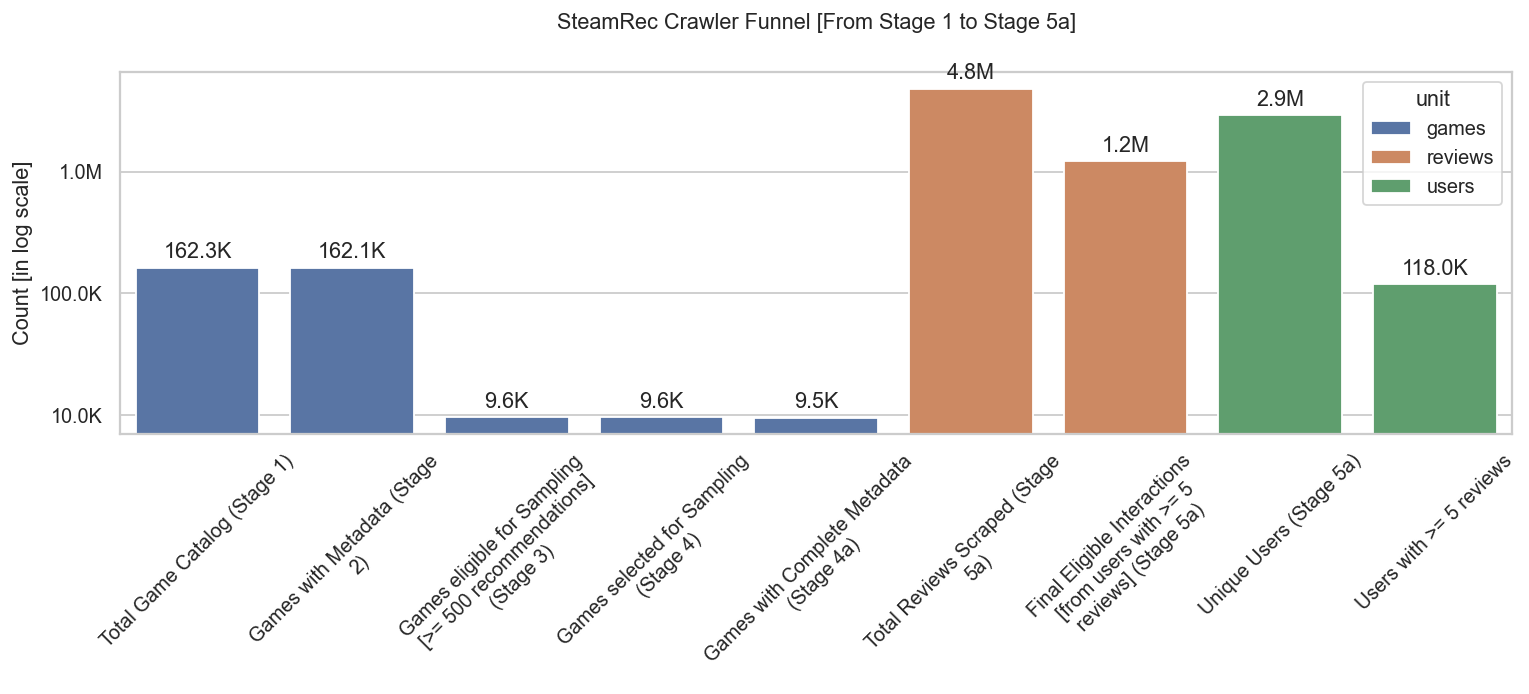

In [127]:
if RUN_REPORT_EDA_DIAGRAMS:
    stage2_success_mask = as_bool(stage2_details_report_df["success"])
    stage2_game_mask = stage2_details_report_df["type"].eq("game")
    stage3_game_mask = stage3_metadata_report_df["type"].eq("game")
    stage3_eligible_mask = as_bool(stage3_metadata_report_df["eligible_for_sampling"])
    stage4a_complete_mask = stage4a_metadata_report_df[
        ["num_reviews", "positive_review_pct", "price", "app_category"]
    ].notna().all(axis=1)

    stage1_games = stage1_apps_report_df["appid"].nunique()
    stage2_successful_games = int(stage2_success_mask.sum())
    stage2_games = int((stage2_success_mask & stage2_game_mask).sum())
    stage3_eligible_games = int((stage3_game_mask & stage3_eligible_mask).sum())
    stage4_selected_games = stage4_selected_report_df["appid"].nunique()
    stage4a_metadata_rows = int(stage4a_complete_mask.sum())
    stage5a_total_reviews = int(stage5a_reviews_report_df.shape[0])
    stage5a_unique_users = int(stage5a_reviews_report_df["user_id"].nunique())
    kept_sequence_users = int(steamrec_sequences_report_df["user_id"].nunique())
    final_interactions = int(steamrec_interactions_report_df.shape[0])

    funnel_table = pd.DataFrame(
        [
            {
                "stage": f"Total Game Catalog (Stage 1)",
                "unit": "games",
                "count": stage1_games,
                "retention_reference": "",
                "retention_denominator": np.nan,
            },
            {
                "stage": "Games with Metadata (Stage 2)",
                "unit": "games",
                "count": stage2_successful_games,
                "retention_reference": "Total Game Catalog (Stage 1)",
                "retention_denominator": stage1_games,
            },
            {
                "stage": "Games with Metadata (Stage 2)",
                "unit": "games",
                "count": stage2_games,
                "retention_reference": "Games with Metadata (Stage 2)",
                "retention_denominator": stage2_successful_games,
            },
            {
                "stage": "Games eligible for Sampling [>= 500 recommendations] (Stage 3)",
                "unit": "games",
                "count": stage3_eligible_games,
                "retention_reference": "Games with Metadata (Stage 2)",
                "retention_denominator": stage2_games,
            },
            {
                "stage": "Games selected for Sampling (Stage 4)",
                "unit": "games",
                "count": stage4_selected_games,
                "retention_reference": "Games eligible for Sampling [>= 500 recommendations] (Stage 3)",
                "retention_denominator": stage3_eligible_games,
            },
            {
                "stage": "Games with Complete Metadata (Stage 4a)",
                "unit": "games",
                "count": stage4a_metadata_rows,
                "retention_reference": "Games selected for sampling (Stage 4)",
                "retention_denominator": stage4_selected_games,
            },
            {
                "stage": "Total Reviews Scraped (Stage 5a)",
                "unit": "reviews",
                "count": stage5a_total_reviews,
                "retention_reference": "",
                "retention_denominator": np.nan,
            },
            {
                "stage": f"Final Eligible Interactions [from users with >= {USER_REVIEW_COUNT_THRESHOLD_REPORT} reviews] (Stage 5a)",
                "unit": "reviews",
                "count": final_interactions,
                "retention_reference": "Total Reviews Scraped (Stage 5a)",
                "retention_denominator": stage5a_total_reviews,
            },
            {
                "stage": f"Unique Users (Stage 5a)",
                "unit": "users",
                "count": stage5a_unique_users,
                "retention_reference": "",
                "retention_denominator": np.nan,
            },
            {
                "stage": f"Users with >= {USER_REVIEW_COUNT_THRESHOLD_REPORT} reviews",
                "unit": "users",
                "count": kept_sequence_users,
                "retention_reference": f"Unique Users (Stage 5a)",
                "retention_denominator": stage5a_unique_users,
            },
        ]
    )
    funnel_table["retention_vs_reference"] = funnel_table["count"] / funnel_table["retention_denominator"]
    funnel_display = funnel_table[["stage", "unit", "count", "retention_reference", "retention_vs_reference"]].copy()
    funnel_display["count"] = funnel_display["count"].map(lambda value: f"{value:,.0f}")
    funnel_display["retention_vs_reference"] = funnel_display["retention_vs_reference"].map(
        lambda value: "" if pd.isna(value) else f"{value:.2%}"
    )
    display(funnel_display)

    plt.figure(figsize=(12, 5.5))
    # Wrap x-tick labels to max 28 chars per line, break at spaces
    def wrap_label(label, width=28):
        return "\n".join(textwrap.wrap(label, width=width, break_long_words=False, replace_whitespace=False))
    funnel_table_wrapped = funnel_table.copy()
    funnel_table_wrapped["stage_wrapped"] = funnel_table_wrapped["stage"].apply(lambda s: wrap_label(s, width=28))
    ax = sns.barplot(data=funnel_table_wrapped, x="stage_wrapped", y="count", hue="unit", dodge=False)
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(axis_count_formatter))
    ax.set_xlabel("")
    ax.set_ylabel("Count [in log scale]")
    ax.set_title("SteamRec Crawler Funnel [From Stage 1 to Stage 5a]", pad=24)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="center")

    for container in ax.containers:
        ax.bar_label(container, labels=[count_label(value) for value in container.datavalues], padding=3)

    save_report_figure("steamrec_stage_funnel.png")
else:
    print('Skipping this report EDA cell. Set RUN_REPORT_EDA_DIAGRAMS=True to run it.')


,total_game_rows,games_with_recommendations_total,games_missing_recommendations_total,mean,median,p75,p90,p95,max,above_min_recommendations
Stage 2 games,162102,21382.0,140720,5122.29,407.0,1383.00,5568.7,14214.3,5029425.0,9598
Stage 4 selected games,9598,9598.0,0,11130.40,1675.0,4715.25,16102.0,36832.1,5029425.0,9598


Saved figure: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/report/steamrec_stage2_recommendations_selected_vs_all.png


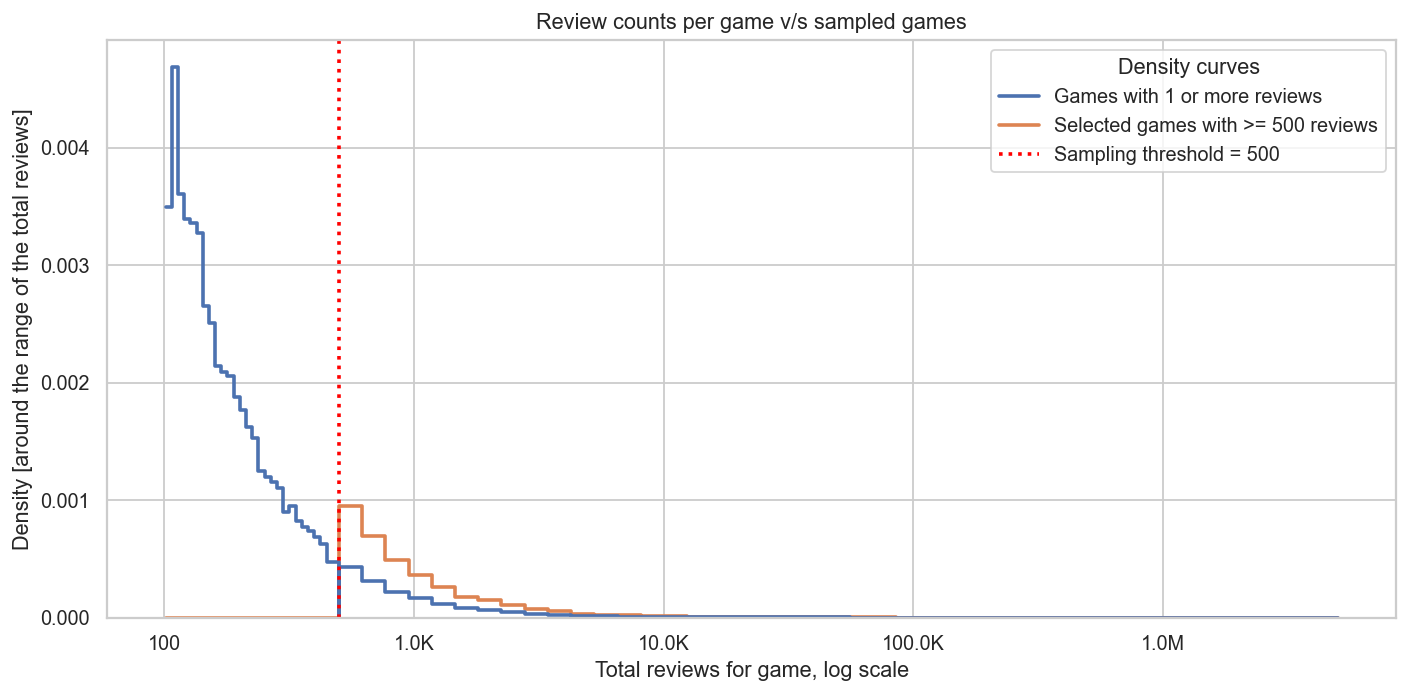

In [128]:
if RUN_REPORT_EDA_DIAGRAMS:
    stage2_games_recs = stage2_details_report_df.loc[
        stage2_success_mask & stage2_game_mask,
        ["appid", "recommendations_total"],
    ].copy()
    stage2_games_recs["recommendations_total"] = pd.to_numeric(
        stage2_games_recs["recommendations_total"], errors="coerce"
    ).clip(lower=0)

    selected_stage2_recs = stage4_selected_report_df[["appid", "recommendations_total"]].copy()
    selected_stage2_recs["recommendations_total"] = pd.to_numeric(
        selected_stage2_recs["recommendations_total"], errors="coerce"
    ).clip(lower=0)

    recommendation_summary = pd.DataFrame(
        {
            "Stage 2 games": numeric_summary(stage2_games_recs["recommendations_total"]),
            "Stage 4 selected games": numeric_summary(selected_stage2_recs["recommendations_total"]),
        }
    ).T.rename(columns={"count": "games_with_recommendations_total"})
    recommendation_summary.insert(
        0,
        "total_game_rows",
        [stage2_games_recs.shape[0], selected_stage2_recs.shape[0]],
    )
    recommendation_summary.insert(
        2,
        "games_missing_recommendations_total",
        [
            int(stage2_games_recs["recommendations_total"].isna().sum()),
            int(selected_stage2_recs["recommendations_total"].isna().sum()),
        ],
    )
    recommendation_summary["above_min_recommendations"] = [
        int((stage2_games_recs["recommendations_total"] > MIN_RECOMMENDATIONS_KNOB).sum()),
        int((selected_stage2_recs["recommendations_total"] > MIN_RECOMMENDATIONS_KNOB).sum()),
    ]
    display(recommendation_summary.round(2))

    plot_recs_df = pd.concat(
        [
            stage2_games_recs.assign(group="Stage 2 games"),
            selected_stage2_recs.assign(group="Stage 4 selected"),
        ],
        ignore_index=True,
    )
    plot_recs_df = plot_recs_df.dropna(subset=["recommendations_total"]).copy()
    plot_recs_df["recommendations_plot"] = plot_recs_df["recommendations_total"].clip(lower=1)
    min_recommendations = plot_recs_df["recommendations_plot"].min()
    max_recommendations = plot_recs_df["recommendations_plot"].max()
    if min_recommendations < MIN_RECOMMENDATIONS_KNOB < max_recommendations:
        bins_below_threshold = np.logspace(
            np.log10(min_recommendations),
            np.log10(MIN_RECOMMENDATIONS_KNOB),
            28,
            endpoint=False,
        )
        bins_above_threshold = np.logspace(
            np.log10(MIN_RECOMMENDATIONS_KNOB),
            np.log10(max_recommendations),
            44,
        )
        bins = np.unique(
            np.concatenate(
                [
                    bins_below_threshold,
                    [MIN_RECOMMENDATIONS_KNOB],
                    bins_above_threshold,
                ]
            )
        )
    else:
        bins = np.logspace(np.log10(min_recommendations), np.log10(max_recommendations), 70)

    recommendation_palette = {
        "Stage 2 games": "#4C72B0",
        "Stage 4 selected": "#DD8452",
    }

    plt.figure(figsize=(11, 5.5))
    ax = sns.histplot(
        data=plot_recs_df,
        x="recommendations_plot",
        hue="group",
        hue_order=["Stage 2 games", "Stage 4 selected"],
        palette=recommendation_palette,
        bins=bins,
        element="step",
        stat="density",
        common_norm=False,
        fill=False,
        linewidth=2,
        legend=False,
    )
    ax.axvline(
        MIN_RECOMMENDATIONS_KNOB,
        color="red",
        linestyle=":",
        linewidth=2,
        label=f"Sampling threshold = {MIN_RECOMMENDATIONS_KNOB:,}",
    )
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(FuncFormatter(axis_count_formatter))
    ax.set_xlabel("Total reviews for game, log scale")
    ax.set_ylabel("Density [around the range of the total reviews]")
    ax.set_title("Review counts per game v/s sampled games")
    legend_handles = [
        Line2D(
            [0],
            [0],
            color=recommendation_palette["Stage 2 games"],
            linewidth=2,
            label="Games with 1 or more reviews",
        ),
        Line2D(
            [0],
            [0],
            color=recommendation_palette["Stage 4 selected"],
            linewidth=2,
            label=f"Selected games with >= {MIN_RECOMMENDATIONS_KNOB} reviews",
        ),
        Line2D(
            [0],
            [0],
            color="red",
            linestyle=":",
            linewidth=2,
            label=f"Sampling threshold = {MIN_RECOMMENDATIONS_KNOB:,}",
        ),
    ]
    ax.legend(handles=legend_handles, loc="upper right", title="Density curves")

    save_report_figure("steamrec_stage2_recommendations_selected_vs_all.png")
else:
    print('Skipping this report EDA cell. Set RUN_REPORT_EDA_DIAGRAMS=True to run it.')

,metric,value
0,selected_apps,9598
1,rows_with_num_reviews,9598
2,rows_with_positive_pct,9598
3,rows_with_price,9523
4,free_games,168
5,paid_games,9355


,category_description,count
6,Indie,5837
0,Action,4416
7,Adventure,4327
8,Simulation,2739
2,RPG,2655
3,Casual,2483
1,Strategy,2280
12,Early Access,681
4,Racing,339
5,Sports,328


,price_bucket,apps,median_positive_pct,median_public_reviews
0,Free,168,77.50,1431.5
1,\$0 to \$10,4301,87.27,1318.0
2,\$10 to \$30,4357,86.71,1912.0
3,\$30 to \$60,667,82.57,4718.0
4,\$60 plus,30,73.66,11378.0


Saved figure: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/report/steamrec_metadata_genres_and_price.png


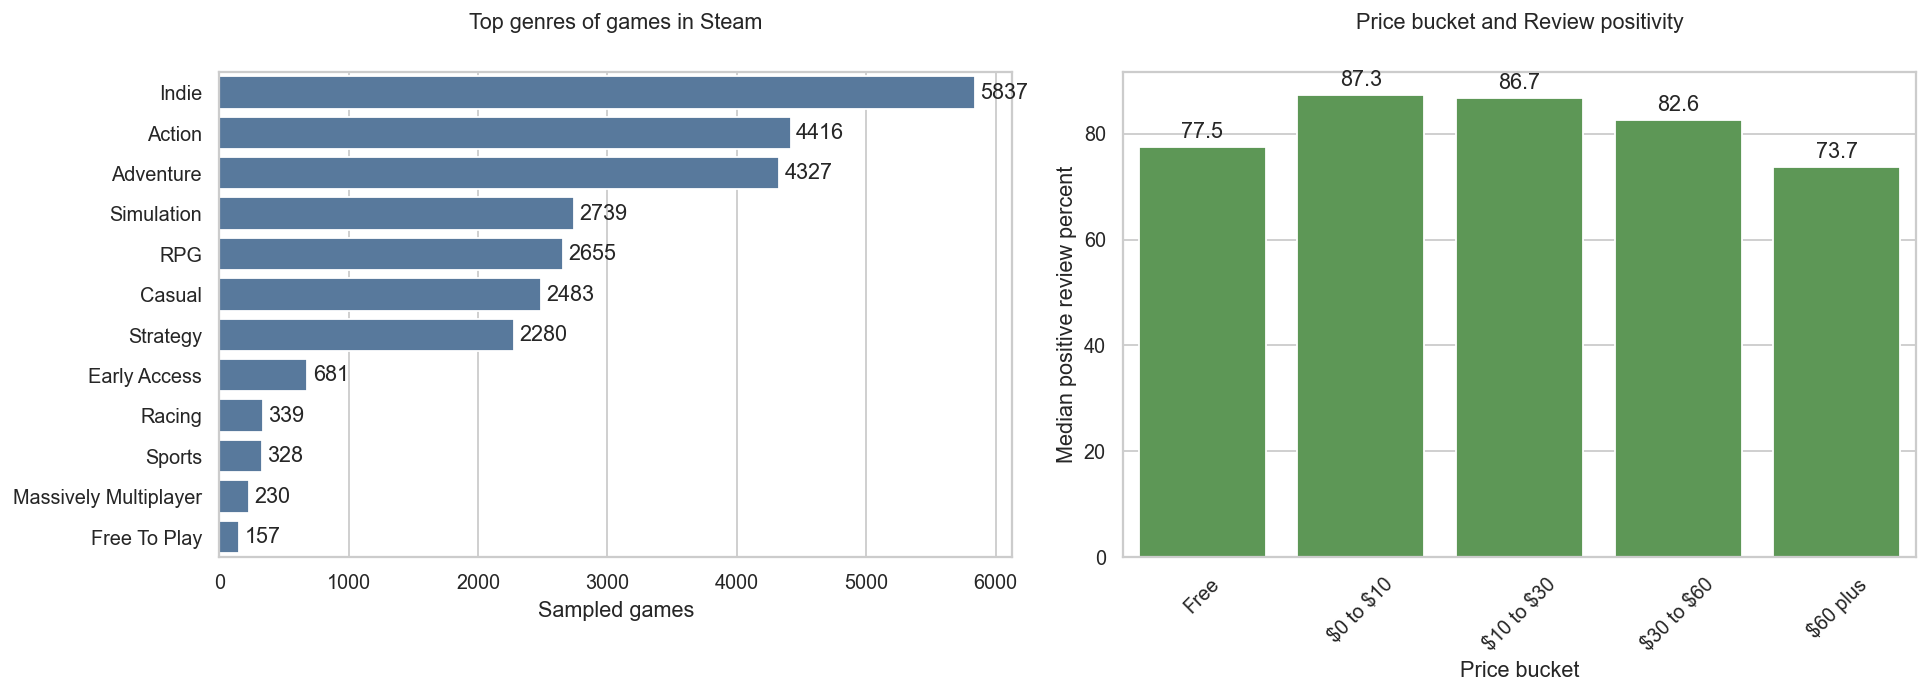

In [129]:
if RUN_REPORT_EDA_DIAGRAMS:
    metadata_summary = pd.DataFrame(
        [
            ("selected_apps", stage4a_metadata_report_df["appid"].nunique()),
            ("rows_with_num_reviews", stage4a_metadata_report_df["num_reviews"].notna().sum()),
            ("rows_with_positive_pct", stage4a_metadata_report_df["positive_review_pct"].notna().sum()),
            ("rows_with_price", stage4a_metadata_report_df["price"].notna().sum()),
            ("free_games", stage4a_metadata_report_df["price"].eq(0).sum()),
            ("paid_games", stage4a_metadata_report_df["price"].gt(0).sum()),
        ],
        columns=["metric", "value"],
    )
    display(metadata_summary)

    label_column = "category_description" if "category_description" in steamrec_genres_report_df.columns else "app_category"
    top_genres_report_df = steamrec_genres_report_df.sort_values("count", ascending=False).head(12)
    price_bucket_df = stage4a_metadata_report_df.copy()
    price_bucket_df["price_bucket"] = pd.cut(
        price_bucket_df["price"],
        bins=[-0.01, 0, 10, 30, 60, np.inf],
        labels=["Free", "\\$0 to \\$10", "\\$10 to \\$30", "\\$30 to \\$60", "\\$60 plus"],
    )
    price_bucket_summary = (
        price_bucket_df.groupby("price_bucket", observed=True)
        .agg(
            apps=("appid", "nunique"),
            median_positive_pct=("positive_review_pct", "median"),
            median_public_reviews=("num_reviews", "median"),
        )
        .reset_index()
    )
    display(top_genres_report_df[[label_column, "count"]])
    display(price_bucket_summary.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    sns.barplot(data=top_genres_report_df, y=label_column, x="count", color="#4C78A8", ax=axes[0])
    axes[0].set_xlabel("Sampled games")
    axes[0].set_ylabel("")
    axes[0].set_title("Top genres of games in Steam", pad=24)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt="%.0f", padding=3)

    sns.barplot(data=price_bucket_summary, x="price_bucket", y="median_positive_pct", color="#54A24B", ax=axes[1])
    axes[1].set_xlabel("Price bucket")
    axes[1].set_ylabel("Median positive review percent")
    axes[1].set_title("Price bucket and Review positivity", pad=24)
    axes[1].tick_params(axis="x", rotation=45)
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt="%.1f", padding=3)

    save_report_figure("steamrec_metadata_genres_and_price.png")
else:
    print('Skipping this report EDA cell. Set RUN_REPORT_EDA_DIAGRAMS=True to run it.')


,count,mean,median,p75,p90,p95,max,apps_below_500_public_reviews,apps_above_sampling_threshold
public_num_reviews,9598.0,11130.4,1675.0,4715.25,16102.0,36832.1,5029425.0,0,9598


Saved figure: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/report/steamrec_public_num_reviews_distribution.png


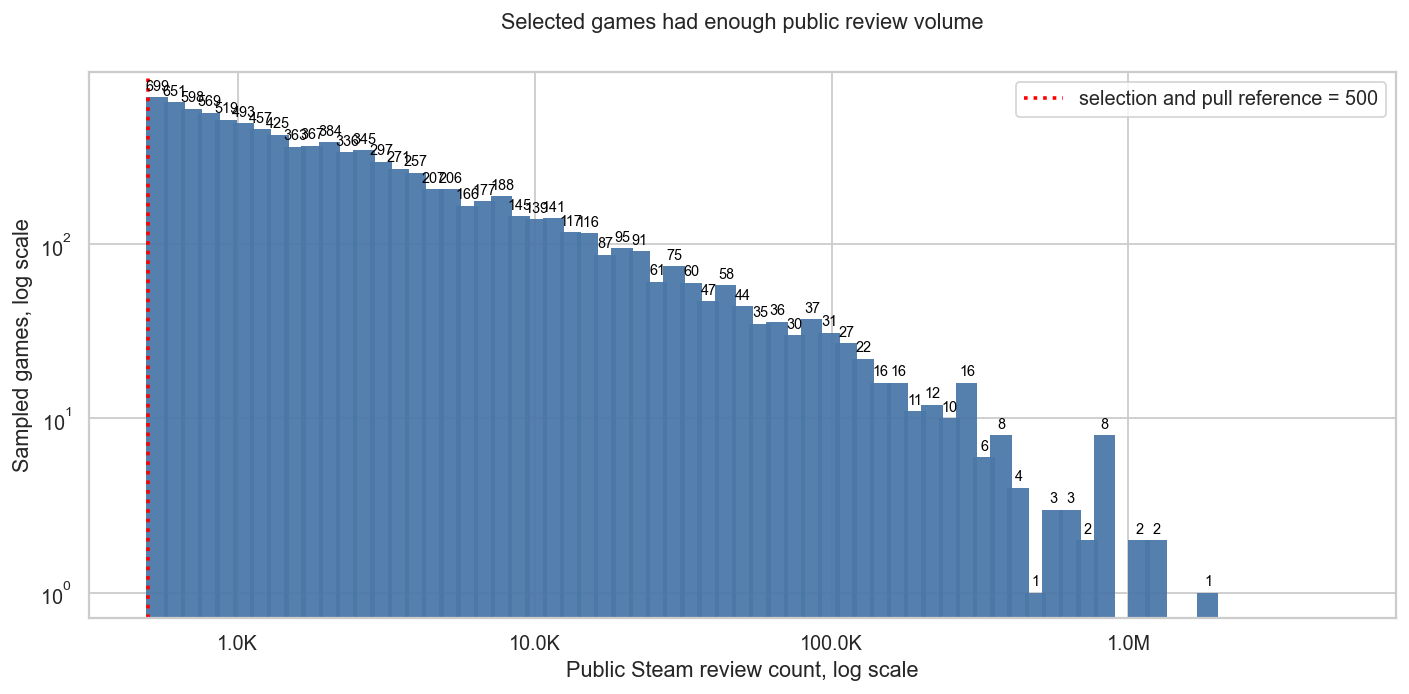

In [130]:
if RUN_REPORT_EDA_DIAGRAMS:
    public_review_summary = numeric_summary(stage4a_metadata_report_df["num_reviews"]).to_frame("public_num_reviews").T
    public_review_summary["apps_below_500_public_reviews"] = int(
        stage4a_metadata_report_df["num_reviews"].lt(REPORT_REVIEW_ROW_TARGET_HINT).sum()
    )
    public_review_summary["apps_above_sampling_threshold"] = int(
        stage4a_metadata_report_df["num_reviews"].gt(MIN_RECOMMENDATIONS_KNOB).sum()
    )
    display(public_review_summary.round(2))

    plot_public_reviews_df = stage4a_metadata_report_df[["appid", "num_reviews"]].dropna().copy()
    plot_public_reviews_df["num_reviews_plot"] = plot_public_reviews_df["num_reviews"].clip(lower=1)

    # Compute log-scale bins for the y-axis (count/bin height)
    # For log y-bins, we need to use numpy histogram, then create a barplot from the result
    from numpy import logspace, log10, linspace

    # For the x-axis: num_reviews_plot, we want to keep log-spaced bins, so bins below will be for num_reviews_plot axis, not y
    x_min = plot_public_reviews_df["num_reviews_plot"].min()
    x_max = plot_public_reviews_df["num_reviews_plot"].max()
    n_bins = 70
    log_bins = np.logspace(np.log10(x_min), np.log10(x_max), n_bins)

    plt.figure(figsize=(11, 5.5))
    ax = sns.histplot(
        plot_public_reviews_df["num_reviews_plot"],
        bins=log_bins,
        color="#4C78A8",
        linewidth=0,
        alpha=0.95,
        edgecolor=None,
        shrink=1.0,
    )

    # Visually widen bars without changing the histogram bins/counts.
    bar_width_factor = 1.25
    for patch in ax.patches:
        left = patch.get_x()
        right = left + patch.get_width()
        if left <= 0 or right <= 0:
            continue

        log_left = np.log(left)
        log_right = np.log(right)
        log_center = (log_left + log_right) / 2
        new_log_left = log_center - (log_center - log_left) * bar_width_factor
        new_log_right = log_center + (log_right - log_center) * bar_width_factor

        patch.set_x(np.exp(new_log_left))
        patch.set_width(np.exp(new_log_right) - np.exp(new_log_left))
        patch.set_linewidth(0)

    # Add value labels on top of the histogram bars,
    # But first, check if ax.patches has bar attributes (matplotlib vs seaborn versions might differ).
    for patch in ax.patches:
        # Patch should have get_height, get_x, get_width methods for bar charts
        try:
            height = patch.get_height()
            if height > 0:
                x = patch.get_x() + patch.get_width() / 2
                ax.annotate(
                    f"{int(height)}",
                    (x, height),
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="black",
                    rotation=0,
                    xytext=(0, 2),
                    textcoords="offset points"
                )
        except AttributeError:
            # In some seaborn/matplotlib combos, these aren't available or needed
            continue
    if MIN_RECOMMENDATIONS_KNOB == REPORT_REVIEW_ROW_TARGET_HINT:
        ax.axvline(
            MIN_RECOMMENDATIONS_KNOB,
            color="red",
            linestyle=":",
            linewidth=2,
            label=f"selection and pull reference = {MIN_RECOMMENDATIONS_KNOB:,}",
        )
    else:
        ax.axvline(
            REPORT_REVIEW_ROW_TARGET_HINT,
            color="red",
            linestyle=":",
            linewidth=2,
            label=f"review rows per game target = {REPORT_REVIEW_ROW_TARGET_HINT:,}",
        )
        ax.axvline(
            MIN_RECOMMENDATIONS_KNOB,
            color="#F58518",
            linestyle=":",
            linewidth=2,
            label=f"sampling threshold = {MIN_RECOMMENDATIONS_KNOB:,}",
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.xaxis.set_major_formatter(FuncFormatter(axis_count_formatter))
    ax.set_xlabel("Public Steam review count, log scale")
    ax.set_ylabel("Sampled games, log scale")
    ax.set_title("Selected games had enough public review volume", pad=24)
    ax.legend()

    save_report_figure("steamrec_public_num_reviews_distribution.png")
else:
    print('Skipping this report EDA cell. Set RUN_REPORT_EDA_DIAGRAMS=True to run it.')

,table,vote,rows,share
1,All extracted reviews,Negative,882987,0.184005
0,All extracted reviews,Positive,3915723,0.815995
3,Sampled reviews from users with more than 5 re...,Negative,252687,0.206462
2,Sampled reviews from users with more than 5 re...,Positive,971204,0.793538


Saved figure: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/report/steamrec_vote_balance_raw_vs_kept.png


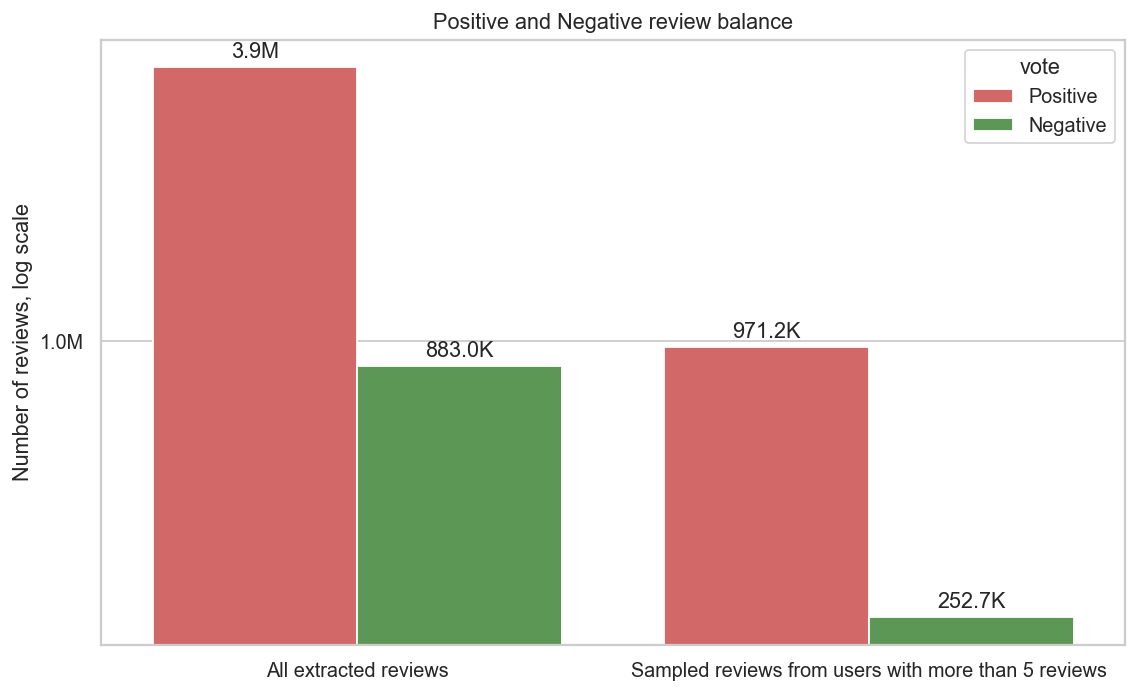

In [131]:
if RUN_REPORT_EDA_DIAGRAMS:
    raw_vote_counts_df = (
        stage5a_reviews_report_df["review_score"]
        .map({-1: "Negative", 1: "Positive"})
        .value_counts(dropna=False)
        .rename_axis("vote")
        .reset_index(name="rows")
    )
    raw_vote_counts_df["table"] = "All extracted reviews"

    kept_vote_counts_df = (
        steamrec_interactions_report_df["rating"]
        .map({-1: "Negative", 1: "Positive"})
        .value_counts(dropna=False)
        .rename_axis("vote")
        .reset_index(name="rows")
    )
    kept_vote_counts_df["table"] = f"Sampled reviews from users with more than {USER_REVIEW_COUNT_THRESHOLD_REPORT} reviews"

    vote_balance_df = pd.concat([raw_vote_counts_df, kept_vote_counts_df], ignore_index=True)
    vote_balance_df["share"] = vote_balance_df["rows"] / vote_balance_df.groupby("table")["rows"].transform("sum")
    display(vote_balance_df[["table", "vote", "rows", "share"]].sort_values(["table", "vote"]))

    plt.figure(figsize=(9, 5.5))
    ax = sns.barplot(data=vote_balance_df, x="table", y="rows", hue="vote", palette=["#E45756", "#54A24B"])
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(axis_count_formatter))
    ax.set_xlabel("")
    ax.set_ylabel("Number of reviews, log scale")
    ax.set_title("Positive and Negative review balance")
    for container in ax.containers:
        ax.bar_label(container, labels=[count_label(value) for value in container.datavalues], padding=3)

    save_report_figure("steamrec_vote_balance_raw_vs_kept.png")
else:
    print('Skipping this report EDA cell. Set RUN_REPORT_EDA_DIAGRAMS=True to run it.')


,metric,value
0,raw_review_users,2927350
1,users_with_at_least_5_reviews,118048
2,users_below_5_reviews,2809302
3,raw_reviews_from_kept_users,1223891
4,raw_reviews_from_dropped_users,3574819
5,final_sequence_users,118048


,count,mean,median,p75,p90,p95,max
raw_reviews_per_user,2927350.0,1.64,1.0,1.0,3.0,4.0,4485.0


Saved figure: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/report/steamrec_user_review_threshold.png


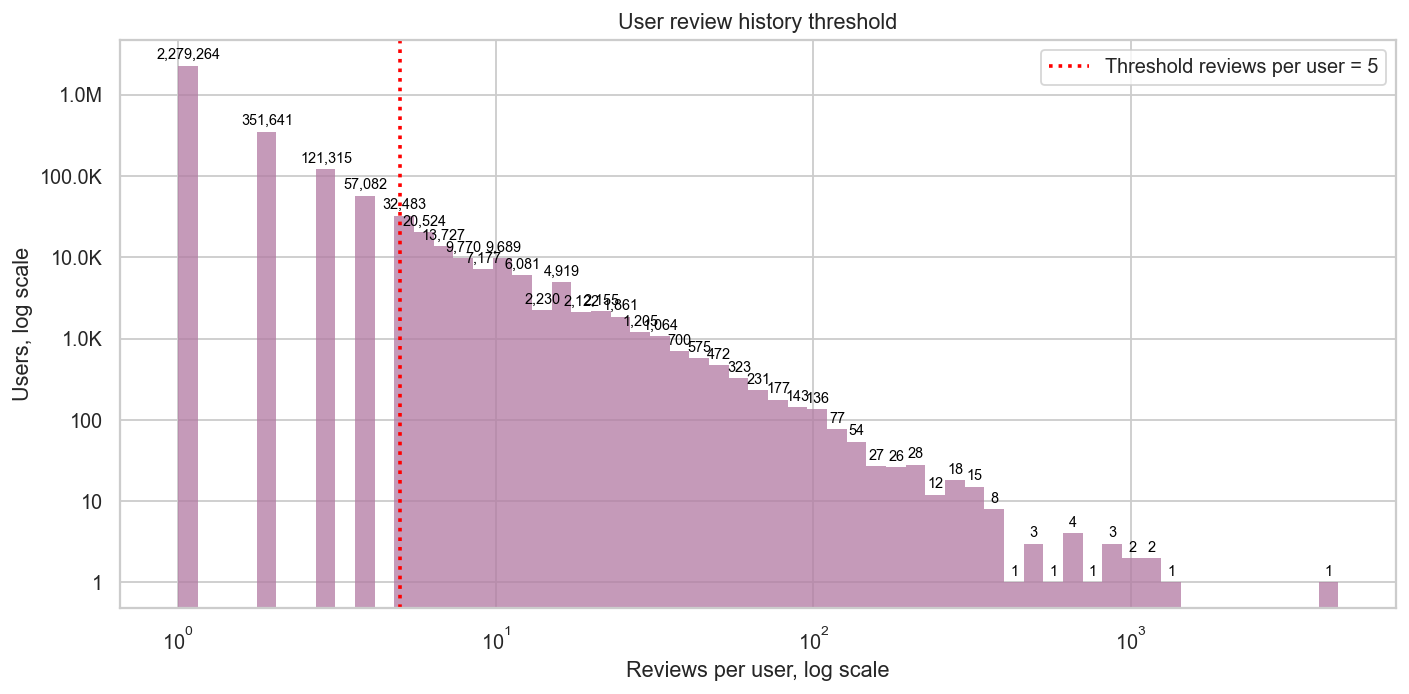

In [132]:
if RUN_REPORT_EDA_DIAGRAMS:
    stage05a_user_review_counts = (
        stage5a_reviews_report_df.groupby("user_id")
        .size()
        .rename("review_count")
        .reset_index()
    )
    stage05a_user_review_counts["kept_for_sequences"] = stage05a_user_review_counts["review_count"].ge(
        USER_REVIEW_COUNT_THRESHOLD_REPORT
    )

    user_threshold_summary = pd.DataFrame(
        [
            ("raw_review_users", stage05a_user_review_counts["user_id"].nunique()),
            (f"users_with_at_least_{USER_REVIEW_COUNT_THRESHOLD_REPORT}_reviews", int(stage05a_user_review_counts["kept_for_sequences"].sum())),
            (f"users_below_{USER_REVIEW_COUNT_THRESHOLD_REPORT}_reviews", int((~stage05a_user_review_counts["kept_for_sequences"]).sum())),
            ("raw_reviews_from_kept_users", int(stage05a_user_review_counts.loc[stage05a_user_review_counts["kept_for_sequences"], "review_count"].sum())),
            ("raw_reviews_from_dropped_users", int(stage05a_user_review_counts.loc[~stage05a_user_review_counts["kept_for_sequences"], "review_count"].sum())),
            ("final_sequence_users", steamrec_sequences_report_df["user_id"].nunique()),
        ],
        columns=["metric", "value"],
    )
    display(user_threshold_summary)
    display(numeric_summary(stage05a_user_review_counts["review_count"]).to_frame("raw_reviews_per_user").T.round(2))

    plt.figure(figsize=(11, 5.5))
    clipped_review_counts = stage05a_user_review_counts["review_count"]
    max_review_count = stage05a_user_review_counts["review_count"].max()
    bins = np.logspace(0, np.log10(max_review_count), 60)
    ax = sns.histplot(clipped_review_counts, bins=bins, color="#B279A2")

    for patch in ax.patches:
        height = patch.get_height()
        if height <= 0:
            continue

        x = patch.get_x() + patch.get_width() / 2
        ax.annotate(
            f"{int(height):,}",
            (x, height),
            ha="center",
            va="bottom",
            fontsize=8,
            color="black",
            xytext=(0, 2),
            textcoords="offset points",
        )

    ax.axvline(
        USER_REVIEW_COUNT_THRESHOLD_REPORT,
        color="red",
        linestyle=":",
        linewidth=2,
        label=f"Threshold reviews per user = {USER_REVIEW_COUNT_THRESHOLD_REPORT}",
    )
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(axis_count_formatter))
    ax.set_xlabel("Reviews per user, log scale")
    ax.set_ylabel("Users, log scale")
    ax.set_title("User review history threshold")
    ax.legend()

    save_report_figure("steamrec_user_review_threshold.png")
else:
    print('Skipping this report EDA cell. Set RUN_REPORT_EDA_DIAGRAMS=True to run it.')

/var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/ipykernel_44395/4072168219.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  raw_time_df["review_month"] = pd.to_datetime(raw_time_df["timestamp"], unit="s", utc=True).dt.to_period("M").dt.to_timestamp()
/var/folders/fg/p6f6x7z11qb2jtk9d1gdsdlw0000gn/T/ipykernel_44395/4072168219.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  kept_time_df["review_month"] = pd.to_datetime(kept_time_df["timestamp"], unit="s", utc=True).dt.to_period("M").dt.to_timestamp()


series,year,Final interactions based on user profiling,Raw review dataset
4,2015,1926,11232
5,2016,4446,24761
6,2017,9544,43576
7,2018,12468,48292
8,2019,16919,69658
9,2020,31501,133393
10,2021,49110,193647
11,2022,68825,253560
12,2023,110056,376551
13,2024,193435,656265


,series,first_month,last_month,total_reviews,peak_month_reviews
0,Final interactions based on user profiling,2011-07-01,2026-04-01,1223891,99813
1,Raw review dataset,2011-06-01,2026-04-01,4798710,479549


Saved figure: /Users/gitaalekhyapaul/Documents/[Local] CS5242/cs5242-project/steam-crawler/report/steamrec_review_timeline_raw_vs_kept.png


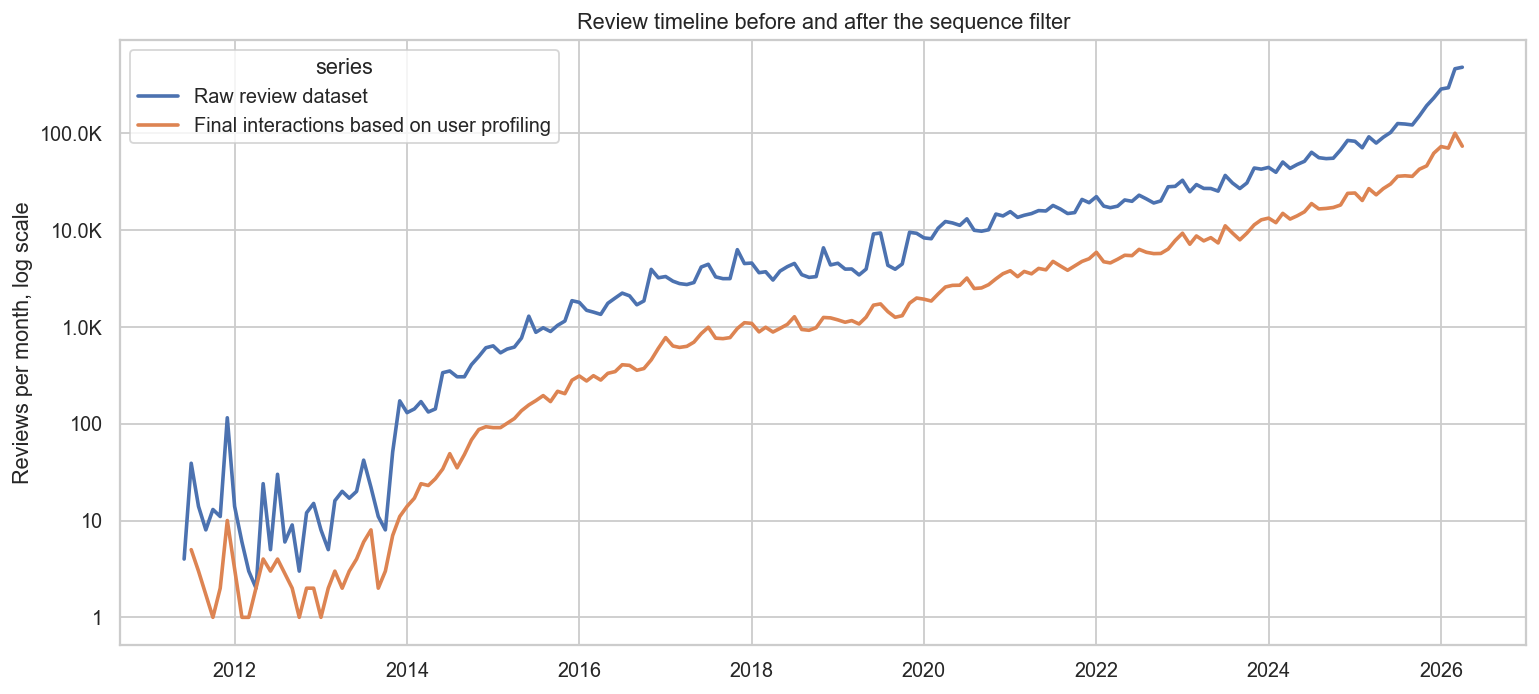

In [133]:
if RUN_REPORT_EDA_DIAGRAMS:
    raw_time_df = stage5a_reviews_report_df[["timestamp"]].dropna().copy()
    raw_time_df["review_month"] = pd.to_datetime(raw_time_df["timestamp"], unit="s", utc=True).dt.to_period("M").dt.to_timestamp()
    raw_monthly_df = raw_time_df.groupby("review_month").size().rename("reviews").reset_index()
    raw_monthly_df["series"] = "Raw review dataset"

    kept_time_df = steamrec_interactions_report_df[["timestamp"]].dropna().copy()
    kept_time_df["review_month"] = pd.to_datetime(kept_time_df["timestamp"], unit="s", utc=True).dt.to_period("M").dt.to_timestamp()
    kept_monthly_df = kept_time_df.groupby("review_month").size().rename("reviews").reset_index()
    kept_monthly_df["series"] = "Final interactions based on user profiling"

    temporal_monthly_df = pd.concat([raw_monthly_df, kept_monthly_df], ignore_index=True)
    temporal_yearly_df = temporal_monthly_df.copy()
    temporal_yearly_df["year"] = temporal_yearly_df["review_month"].dt.year
    temporal_yearly_summary = (
        temporal_yearly_df.groupby(["series", "year"])["reviews"]
        .sum()
        .reset_index()
        .pivot(index="year", columns="series", values="reviews")
        .fillna(0)
        .astype(int)
        .reset_index()
    )
    display(temporal_yearly_summary.tail(12))

    coverage_summary = temporal_monthly_df.groupby("series").agg(
        first_month=("review_month", "min"),
        last_month=("review_month", "max"),
        total_reviews=("reviews", "sum"),
        peak_month_reviews=("reviews", "max"),
    ).reset_index()
    display(coverage_summary)

    plt.figure(figsize=(12, 5.5))
    ax = sns.lineplot(data=temporal_monthly_df, x="review_month", y="reviews", hue="series", linewidth=2)
    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(FuncFormatter(axis_count_formatter))
    ax.set_xlabel("")
    ax.set_ylabel("Reviews per month, log scale")
    ax.set_title("Review timeline before and after the sequence filter")

    save_report_figure("steamrec_review_timeline_raw_vs_kept.png")
else:
    print('Skipping this report EDA cell. Set RUN_REPORT_EDA_DIAGRAMS=True to run it.')
